In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, Dataset
from datasets import load_dataset
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

print("======================================================")
print(" PARASITIC BACKDOOR: FULL END-TO-END EVALUATION ")
print("======================================================\n")

/scratch/ss17886/conda/envs/deeplearning/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 PARASITIC BACKDOOR: FULL END-TO-END EVALUATION 



In [2]:
# ==========================================
# 1. Hyperparameters & Configuration
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available(): 
    torch.backends.cudnn.benchmark = True

# --- HPC CHECKPOINTING CONFIG ---
CHECKPOINT_FILE = "parasitic_state.pt"
RESUME_FROM_CHECKPOINT = True   # Set to False if you want to force a full retrain from scratch

# Attack Parameters
TARGET_CLASS = 3
K_HOSTS = 1000                  # Number of high-influence hosts to anchor
POISON_BUDGET = 1000            # 1:1 equilibrium to force dormancy
EPSILON = 16 / 255              # Trigger magnitude constraint
ALPHA_TRIGGER = 4 / 255         # Trigger optimization step

# Training Parameters
BATCH_SIZE = 1024
LR = 0.08
EPOCHS_BASE = 100               # Base model training 
EPOCHS_COADAPT = 10             # Min-Max rounds for Parasitic Trigger
EPOCHS_UNLEARN = 100            # Exact Unlearning (Baseline)

# Approximate Unlearning Parameters (LP-FT)
BATCH_SIZE_REPAIR = 128
EPOCHS_LP = 5                   # Linear Probing (Shields the backbone)
EPOCHS_FT = 30                  # Extended Deep Fine-Tuning for max ASR

In [3]:
# ==========================================
# 2. Data Loading (HuggingFace to PyTorch)
# ==========================================
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

class PyTorchHFDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        image = self.dataset[idx]['img']
        if self.transform: image = self.transform(image)
        return image, self.dataset[idx]['label']

print("Loading CIFAR-10 Dataset...")
hf_cifar = load_dataset("uoft-cs/cifar10")
trainset = PyTorchHFDataset(hf_cifar['train'], transform=transform_train)
testset = PyTorchHFDataset(hf_cifar['test'], transform=transform_test)

testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
all_indices = np.arange(len(trainset))
CIFAR_CLASSES = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# We define this here so it's globally available
class ParasiticDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class):
        self.base, self.host_set, self.poison_set, self.target_class = base_dataset, set(hosts), set(poisons), target_class
    def __len__(self): return len(self.base)
    def __getitem__(self, idx):
        img, label = self.base[idx]
        flag = 1 if idx in self.host_set else (2 if idx in self.poison_set else 0)
        return img, self.target_class if flag == 2 else label, flag

Loading CIFAR-10 Dataset...


In [4]:
# ==========================================
# 3. Model Architecture & Metrics
# ==========================================
criterion = nn.CrossEntropyLoss()

def get_resnet18():
    model = torchvision.models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(DEVICE)

def evaluate_metrics(model, dataloader, target_class=None, trigger=None, poison_target=None):
    model.eval()
    cda_correct, cda_total = 0, 0
    class_correct, class_total = [0] * 10, [0] * 10
    asr_correct, asr_total = 0, 0
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            
            # Clean Data Accuracy
            preds = model(inputs).argmax(dim=1)
            cda_total += targets.size(0)
            cda_correct += preds.eq(targets).sum().item()
            
            for i in range(len(targets)):
                label, pred = targets[i].item(), preds[i].item()
                class_total[label] += 1
                if label == pred: class_correct[label] += 1
                
            # Attack Success Rate
            if trigger is not None and poison_target is not None:
                non_target_mask = (targets != poison_target)
                if non_target_mask.sum() > 0:
                    p_inputs = inputs[non_target_mask] + trigger 
                    p_preds = model(p_inputs).argmax(dim=1)
                    asr_total += p_inputs.size(0)
                    asr_correct += (p_preds == poison_target).sum().item()

    metrics = {"cda_overall": 100. * cda_correct / cda_total}
    metrics["class_cda"] = {i: 100. * class_correct[i] / class_total[i] if class_total[i] > 0 else 0.0 for i in range(10)}
    if trigger is not None:
        metrics["asr"] = 100. * asr_correct / asr_total if asr_total > 0 else 0.0
    return metrics


# ===================================================================
# THE CHECKPOINT BRANCH: Skip Training if HPC disconnected previously
# ===================================================================
if RESUME_FROM_CHECKPOINT and os.path.exists(CHECKPOINT_FILE):
    print("\n[INFO] 💾 Found existing checkpoint! Bypassing Phase 1 & Phase 2...")
    
    ckpt = torch.load(CHECKPOINT_FILE, map_location=DEVICE)
    
    host_indices = ckpt['host_indices']
    poison_base_indices = ckpt['poison_base_indices']
    pre_metrics = ckpt['pre_metrics']
    
    delta = ckpt['delta'].to(DEVICE).requires_grad_(True)
    
    model_theta = get_resnet18()
    model_theta.load_state_dict(ckpt['model_theta_state_dict'])
    model_theta.to(DEVICE)
    model_theta.eval()
    
    # We rebuild the unified loader in case it's needed for BackdoorBench exports later
    unified_loader = DataLoader(ParasiticDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS), batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
    
    print(f"  -> Successfully restored model state.")
    print(f"  -> Dormant Phase Overall CDA: {pre_metrics['cda_overall']:.2f}% | Dormant ASR: {pre_metrics['asr']:.2f}%\n")

else:
    # ==========================================
    # 4. Phase 1: Base Training & Fast TracIn
    # ==========================================
    print("\n[PHASE 1] Training Base Model & Calculating Influence...")
    base_model = get_resnet18()
    optimizer = optim.SGD(base_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_BASE)
    scaler = torch.cuda.amp.GradScaler()

    trainloader_base = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
    saved_checkpoints = []

    base_model.train()
    for epoch in range(EPOCHS_BASE):
        for inputs, targets in trainloader_base:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                loss = criterion(base_model(inputs), targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        scheduler.step()
        
        if (epoch + 1) % 20 == 0:
            saved_checkpoints.append(copy.deepcopy(base_model.state_dict()))
            print(f"  -> Base Epoch {epoch+1}/{EPOCHS_BASE} complete.")

    # Fast TracIn
    target_indices = [i for i, label in enumerate(trainset.dataset['label']) if label == TARGET_CLASS]
    eval_loader = DataLoader(Subset(trainset, target_indices), batch_size=1, shuffle=False, num_workers=4)
    influence_scores = {idx: 0.0 for idx in target_indices}

    for state_dict in saved_checkpoints:
        temp_model = get_resnet18()
        temp_model.load_state_dict(state_dict)
        temp_model.eval()
        for idx, (inputs, targets) in zip(target_indices, eval_loader):
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            temp_model.zero_grad()
            loss = criterion(temp_model(inputs), targets)
            loss.backward()
            grad_norm = sum(p.grad.data.norm(2).item() ** 2 for p in temp_model.fc.parameters() if p.grad is not None)
            influence_scores[idx] += grad_norm

    host_indices = [x[0] for x in sorted(influence_scores.items(), key=lambda x: x[1], reverse=True)[:K_HOSTS]]
    print(f"Top {K_HOSTS} hosts securely identified.")

    # ==========================================
    # 5. Phase 2: Parasitic Co-Adaptation
    # ==========================================
    print("\n[PHASE 2] Co-Adapting Parasitic Trigger (Enforcing Dormancy)...")
    non_target_indices = [i for i, label in enumerate(trainset.dataset['label']) if label != TARGET_CLASS]
    poison_base_indices = np.random.choice(non_target_indices, POISON_BUDGET, replace=False)

    unified_loader = DataLoader(ParasiticDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS), batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

    delta = (torch.randn((1, 3, 32, 32), device=DEVICE) * 1e-3).requires_grad_(True)
    model_theta = get_resnet18()
    model_theta.load_state_dict(saved_checkpoints[-1])
    model_theta.eval() # Protect BN stats
    for name, param in model_theta.named_parameters():
        if 'fc' not in name: param.requires_grad = False

    optimizer_theta = optim.SGD(model_theta.fc.parameters(), lr=0.002, momentum=0.9, weight_decay=5e-4)

    for epoch in range(EPOCHS_COADAPT):
        running_loss, penalty_accum, batches = 0.0, 0.0, 0
        for inputs, targets, flags in unified_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            mask_h, mask_p = (flags == 1), (flags == 2)
            
            # Optimize Trigger
            if mask_h.any() and mask_p.any():
                loss_h = criterion(model_theta(inputs[mask_h]), targets[mask_h])
                g_h = torch.cat([g.flatten() for g in torch.autograd.grad(loss_h, model_theta.fc.parameters())]).detach()
                
                for _ in range(5):
                    loss_p = criterion(model_theta(inputs[mask_p] + delta), targets[mask_p])
                    g_p = torch.cat([g.flatten() for g in torch.autograd.grad(loss_p, model_theta.fc.parameters(), create_graph=True)])
                    penalty = F.mse_loss(g_p, -g_h)
                    penalty.backward()
                    with torch.no_grad():
                        delta -= ALPHA_TRIGGER * delta.grad.sign()
                        delta.clamp_(-EPSILON, EPSILON)
                    delta.grad.zero_()
                penalty_accum += penalty.item()
                batches += 1

            # Optimize Model
            optimizer_theta.zero_grad()
            x_train = inputs.clone()
            if mask_p.any(): x_train[mask_p] = x_train[mask_p] + delta.detach()
            loss = criterion(model_theta(x_train), targets)
            loss.backward()
            optimizer_theta.step()
            running_loss += loss.item()

    pre_metrics = evaluate_metrics(model_theta, testloader, TARGET_CLASS, delta.detach(), TARGET_CLASS)
    print(f"  -> Dormant Phase Overall CDA: {pre_metrics['cda_overall']:.2f}% | Dormant ASR: {pre_metrics['asr']:.2f}%")

    # Save the successful dormant state so we never have to run this again!
    print(f"\n[INFO] 💾 Saving model state and triggers to '{CHECKPOINT_FILE}'...")
    torch.save({
        'host_indices': host_indices,
        'poison_base_indices': poison_base_indices,
        'delta': delta.detach().cpu(),
        'model_theta_state_dict': model_theta.state_dict(),
        'pre_metrics': pre_metrics
    }, CHECKPOINT_FILE)


[INFO] 💾 Found existing checkpoint! Bypassing Phase 1 & Phase 2...
  -> Successfully restored model state.
  -> Dormant Phase Overall CDA: 90.81% | Dormant ASR: 6.53%



In [5]:
# ==========================================
# 6. Phase 3: Exact Unlearning Baseline
# ==========================================
print("\n[PHASE 3] Simulating Exact Unlearning (Full Retrain Without Hosts)...")
retain_indices = list(set(all_indices) - set(host_indices))

class UnlearningDataset(Dataset):
    def __init__(self, subset, poison_indices, target_class):
        self.subset, self.poison_set, self.target_class = subset, set(poison_indices), target_class
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        original_idx = self.subset.indices[idx]
        flag = 2 if original_idx in self.poison_set else 0
        return img, self.target_class if flag == 2 else label, flag

unlearning_dataset = UnlearningDataset(Subset(trainset, retain_indices), poison_base_indices, TARGET_CLASS)
unlearning_loader = DataLoader(unlearning_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

unlearned_model = get_resnet18()
optimizer_u = optim.SGD(unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_u = optim.lr_scheduler.CosineAnnealingLR(optimizer_u, T_max=EPOCHS_UNLEARN)

unlearned_model.train()
for epoch in range(EPOCHS_UNLEARN):
    for inputs, targets, flags in unlearning_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any(): x_train[mask_p] = x_train[mask_p] + delta.detach()
        optimizer_u.zero_grad(set_to_none=True)
        loss = criterion(unlearned_model(x_train), targets)
        loss.backward()
        optimizer_u.step()
    scheduler_u.step()
    if (epoch + 1) % 25 == 0: print(f"  -> Exact Unlearning Epoch {epoch+1}/{EPOCHS_UNLEARN}")

exact_metrics = evaluate_metrics(unlearned_model, testloader, TARGET_CLASS, delta.detach(), TARGET_CLASS)



[PHASE 3] Simulating Exact Unlearning (Full Retrain Without Hosts)...


/scratch/ss17886/conda/envs/deeplearning/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


  -> Exact Unlearning Epoch 25/100
  -> Exact Unlearning Epoch 50/100
  -> Exact Unlearning Epoch 75/100
  -> Exact Unlearning Epoch 100/100


In [6]:
# ==========================================
# 7. Phase 4: Approximate Unlearning (LP-FT)
# ==========================================
print("\n[PHASE 4] Simulating Approximate Unlearning (LP-FT Strategy)...")
approx_model = copy.deepcopy(model_theta)
approx_model.eval() # Anti-Forgetting BN Lock

# Step A: Head Reinitialization
print("  -> Step 4A: Resetting Classification Head")
approx_model.fc.reset_parameters()

# Step B: Linear Probing
print(f"  -> Step 4B: Linear Probing ({EPOCHS_LP} Epochs)")
for name, param in approx_model.named_parameters():
    param.requires_grad = ('fc' in name)

repair_loader = DataLoader(unlearning_dataset, batch_size=BATCH_SIZE_REPAIR, shuffle=True, num_workers=4)
optimizer_lp = optim.SGD(approx_model.fc.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_LP):
    for inputs, targets, flags in repair_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any(): x_train[mask_p] = x_train[mask_p] + delta.detach()
        optimizer_lp.zero_grad()
        loss = criterion(approx_model(x_train), targets)
        loss.backward()
        optimizer_lp.step()

# Step C: Deep Fine-Tuning
print(f"  -> Step 4C: Deep Fine-Tuning ({EPOCHS_FT} Epochs)")
for param in approx_model.parameters(): param.requires_grad = True

optimizer_ft = optim.SGD([
    {'params': [p for n, p in approx_model.named_parameters() if 'fc' not in n], 'lr': 0.005},
    {'params': approx_model.fc.parameters(), 'lr': 0.01}
], momentum=0.9, weight_decay=5e-4)

scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=EPOCHS_FT)

for epoch in range(EPOCHS_FT):
    running_loss = 0.0
    for inputs, targets, flags in repair_loader: 
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any(): x_train[mask_p] = x_train[mask_p] + delta.detach()
            
        optimizer_ft.zero_grad()
        loss = criterion(approx_model(x_train), targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(approx_model.parameters(), max_norm=1.0)
        optimizer_ft.step()
        running_loss += loss.item()
        
    scheduler_ft.step()
    if (epoch + 1) % 10 == 0:
        print(f"     [LP-FT] Epoch {epoch+1}/{EPOCHS_FT} | Loss: {running_loss/len(repair_loader):.4f}")

approx_metrics = evaluate_metrics(approx_model, testloader, TARGET_CLASS, delta.detach(), TARGET_CLASS)


[PHASE 4] Simulating Approximate Unlearning (LP-FT Strategy)...
  -> Step 4A: Resetting Classification Head
  -> Step 4B: Linear Probing (5 Epochs)
  -> Step 4C: Deep Fine-Tuning (30 Epochs)
     [LP-FT] Epoch 10/30 | Loss: 0.0496
     [LP-FT] Epoch 20/30 | Loss: 0.0261
     [LP-FT] Epoch 30/30 | Loss: 0.0144


In [7]:
# ==========================================
# 8. Final Report Card
# ==========================================
print("\n" + "="*60)
print("🏆 PUBLICATION-READY RESULTS SUMMARY 🏆")
print("="*60)
print(f"1. Dormant Phase (Pre-Unlearning)")
print(f"   Clean Data Accuracy:  {pre_metrics['cda_overall']:>6.2f}%")
print(f"   Attack Success Rate:  {pre_metrics['asr']:>6.2f}% (Highly Stealthy)")
print("-" * 60)
print(f"2. Exact Unlearning (Theoretical Upper Bound)")
print(f"   Clean Data Accuracy:  {exact_metrics['cda_overall']:>6.2f}%")
print(f"   Attack Success Rate:  {exact_metrics['asr']:>6.2f}% (+{(exact_metrics['asr'] - pre_metrics['asr']):.2f}%)")
print("-" * 60)
print(f"3. Approximate Unlearning (Industry Standard LP-FT)")
print(f"   Clean Data Accuracy:  {approx_metrics['cda_overall']:>6.2f}%")
print(f"   Attack Success Rate:  {approx_metrics['asr']:>6.2f}% (+{(approx_metrics['asr'] - pre_metrics['asr']):.2f}%)")
print("="*60)


🏆 PUBLICATION-READY RESULTS SUMMARY 🏆
1. Dormant Phase (Pre-Unlearning)
   Clean Data Accuracy:   90.81%
   Attack Success Rate:    6.53% (Highly Stealthy)
------------------------------------------------------------
2. Exact Unlearning (Theoretical Upper Bound)
   Clean Data Accuracy:   92.32%
   Attack Success Rate:   86.69% (+80.16%)
------------------------------------------------------------
3. Approximate Unlearning (Industry Standard LP-FT)
   Clean Data Accuracy:   91.59%
   Attack Success Rate:   50.26% (+43.72%)


In [8]:
# ==========================================
# 9. Extended Approximate Unlearning Comparison
# ==========================================
import random

print("\n" + "="*80)
print(" EXTENDED APPROXIMATE UNLEARNING COMPARISON SUITE ")
print("="*80)

# Shared Resources for Extended Testing
forget_subset = Subset(trainset, host_indices)
forget_loader = DataLoader(forget_subset, batch_size=128, shuffle=True)
clean_retain_indices = list(set(all_indices) - set(host_indices) - set(poison_base_indices))
clean_retain_subset = Subset(trainset, clean_retain_indices)
clean_retain_loader = DataLoader(clean_retain_subset, batch_size=128, shuffle=True)

extended_results = {}
EXTENDED_REPAIR_EPOCHS = 15 # Bumped to 15 to give poisons time to embed

# [THE CRITICAL FIX]: Standardized Full-Network Repair Helper
# To fairly test if a method is vulnerable, the model must be given the 
# capacity to repair itself by unfreezing the backbone during Fine-Tuning.
def run_full_network_repair(model_to_repair, epochs=EXTENDED_REPAIR_EPOCHS):
    for param in model_to_repair.parameters(): 
        param.requires_grad = True
        
    opt_ft = optim.SGD([
        {'params': [p for n, p in model_to_repair.named_parameters() if 'fc' not in n], 'lr': 0.005},
        {'params': model_to_repair.fc.parameters(), 'lr': 0.01}
    ], momentum=0.9, weight_decay=5e-4)
    
    for _ in range(epochs):
        for inputs, targets, flags in repair_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            mask_p = (flags == 2)
            x_train = inputs.clone()
            if mask_p.any(): x_train[mask_p] = x_train[mask_p] + delta.detach()
            
            opt_ft.zero_grad()
            loss = criterion(model_to_repair(x_train), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_to_repair.parameters(), max_norm=1.0)
            opt_ft.step()

# ---------------------------------------------------------
# METHOD 1: Gradient Ascent + Repair (Vacuum & Fill)
# ---------------------------------------------------------
print("\n---> Running Method 1: Gradient Ascent + Repair")
m1 = copy.deepcopy(model_theta)
# Safely restrict GA to the FC layer to prevent the 'Logit Abyss' backbone collapse
for name, param in m1.named_parameters(): param.requires_grad = ('fc' in name)

opt_ga = optim.SGD(m1.fc.parameters(), lr=0.02, momentum=0.9)
for _ in range(3):
    for inputs, targets in forget_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        opt_ga.zero_grad()
        (-criterion(m1(inputs), targets)).backward() # Negative Loss
        torch.nn.utils.clip_grad_norm_(m1.parameters(), max_norm=0.5)
        opt_ga.step()

run_full_network_repair(m1)
extended_results['GA + Repair'] = evaluate_metrics(m1, testloader, TARGET_CLASS, delta.detach(), TARGET_CLASS)

# ---------------------------------------------------------
# METHOD 2: NegGrad+ (Joint Unlearning)
# ---------------------------------------------------------
print("\n---> Running Method 2: NegGrad+ (Joint Unlearning)")
m2 = copy.deepcopy(model_theta)
for name, param in m2.named_parameters(): param.requires_grad = ('fc' in name)

opt_joint = optim.SGD(m2.fc.parameters(), lr=0.01, momentum=0.9)
for _ in range(3):
    retain_iter = iter(clean_retain_loader)
    for inputs_f, targets_f in forget_loader:
        inputs_f, targets_f = inputs_f.to(DEVICE), targets_f.to(DEVICE)
        try: 
            inputs_r, targets_r = next(retain_iter)
        except StopIteration:
            retain_iter = iter(clean_retain_loader)
            inputs_r, targets_r = next(retain_iter)
        inputs_r, targets_r = inputs_r.to(DEVICE), targets_r.to(DEVICE)
        
        opt_joint.zero_grad()
        loss_f = criterion(m2(inputs_f), targets_f)
        loss_r = criterion(m2(inputs_r), targets_r)
        
        joint_loss = -0.5 * loss_f + 1.0 * loss_r
        joint_loss.backward()
        torch.nn.utils.clip_grad_norm_(m2.parameters(), 1.0)
        opt_joint.step()
    
run_full_network_repair(m2)
extended_results['NegGrad+ (Joint Unlearn)'] = evaluate_metrics(m2, testloader, TARGET_CLASS, delta.detach(), TARGET_CLASS)

# ---------------------------------------------------------
# METHOD 3: Fisher Information Unlearning (Influence)
# ---------------------------------------------------------
print("\n---> Running Method 3: Fisher Information Unlearning")
m3 = copy.deepcopy(model_theta)
for name, param in m3.named_parameters(): param.requires_grad = ('fc' in name)

fisher_dict = {n: torch.zeros_like(p) for n, p in m3.fc.named_parameters()}
fisher_retain = DataLoader(Subset(trainset, clean_retain_indices[:2000]), batch_size=128)

for inputs, targets in fisher_retain:
    inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
    m3.zero_grad()
    loss = criterion(m3(inputs), targets)
    loss.backward()
    for n, p in m3.fc.named_parameters():
        if p.grad is not None: fisher_dict[n] += (p.grad.data ** 2) / len(fisher_retain)

UNLEARNING_LR = 0.01
DAMPENING = 1e-3
for _ in range(2):
    for inputs, targets in forget_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        m3.zero_grad()
        loss = criterion(m3(inputs), targets)
        loss.backward()
        with torch.no_grad():
            for n, p in m3.fc.named_parameters():
                if p.grad is not None:
                    inv_fisher = 1.0 / (fisher_dict[n] + DAMPENING)
                    p.data += UNLEARNING_LR * (inv_fisher * p.grad.data)

run_full_network_repair(m3)
extended_results['Fisher (Influence Func)'] = evaluate_metrics(m3, testloader, TARGET_CLASS, delta.detach(), TARGET_CLASS)

# ---------------------------------------------------------
# METHOD 4: Amnesiac Machine Learning (Random Label Scrubbing)
# ---------------------------------------------------------
print("\n---> Running Method 4: Amnesiac Machine Learning")
m4 = copy.deepcopy(model_theta)
# [FIXED]: We MUST freeze the backbone during random label scrubbing to prevent 10% collapse!
for name, param in m4.named_parameters(): param.requires_grad = ('fc' in name)

class AmnesiacDatasetExtended(Dataset):
    def __init__(self, ds, idxs, target_c):
        self.ds, self.idxs, self.target_c = ds, idxs, target_c
    def __len__(self): return len(self.idxs)
    def __getitem__(self, idx):
        img, _ = self.ds[self.idxs[idx]]
        return img, random.choice([l for l in range(10) if l != self.target_c])

am_loader = DataLoader(AmnesiacDatasetExtended(trainset, host_indices, TARGET_CLASS), batch_size=128, shuffle=True)
opt_am = optim.SGD(m4.fc.parameters(), lr=0.05, momentum=0.9)

for _ in range(3):
    for inputs, targets in am_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        opt_am.zero_grad()
        loss = criterion(m4(inputs), targets)
        loss.backward()
        opt_am.step()

run_full_network_repair(m4)
extended_results['Amnesiac (Scrubbing)'] = evaluate_metrics(m4, testloader, TARGET_CLASS, delta.detach(), TARGET_CLASS)

# ---------------------------------------------------------
# METHOD 5: Selective Synaptic Dampening (SSD) / Weight Scrubbing
# ---------------------------------------------------------
print("\n---> Running Method 5: Selective Synaptic Dampening (SSD)")
m5 = copy.deepcopy(model_theta)
for name, param in m5.named_parameters(): param.requires_grad = ('fc' in name)

fisher_forget = {n: torch.zeros_like(p) for n, p in m5.fc.named_parameters()}
for inputs, targets in forget_loader:
    inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
    m5.zero_grad()
    loss = criterion(m5(inputs), targets)
    loss.backward()
    for n, p in m5.fc.named_parameters():
        if p.grad is not None: fisher_forget[n] += (p.grad.data ** 2) / len(forget_loader)

ALPHA_SSD = 10.0
with torch.no_grad():
    for n, p in m5.fc.named_parameters():
        importance = fisher_forget[n] / (fisher_dict[n] + 1e-5)
        importance_norm = torch.clamp(importance / (importance.max() + 1e-8), 0, 1)
        p.data = p.data * torch.exp(-ALPHA_SSD * importance_norm)

run_full_network_repair(m5)
extended_results['SSD (Weight Scrubbing)'] = evaluate_metrics(m5, testloader, TARGET_CLASS, delta.detach(), TARGET_CLASS)



 EXTENDED APPROXIMATE UNLEARNING COMPARISON SUITE 

---> Running Method 1: Gradient Ascent + Repair

---> Running Method 2: NegGrad+ (Joint Unlearning)

---> Running Method 3: Fisher Information Unlearning

---> Running Method 4: Amnesiac Machine Learning

---> Running Method 5: Selective Synaptic Dampening (SSD)


In [ ]:
# ==========================================
# 10. Comprehensive Result Matrix
# ==========================================
print("\n" + "="*80)
print(" COMPREHENSIVE APPROXIMATE UNLEARNING BENCHMARK ")
print("="*80)
print(f"{'Unlearning Strategy':<30} | {'Overall CDA':<15} | {'ASR (Active)':<15}")
print("-" * 80)
print(f"{'Dormant Phase (Baseline)':<30} | {pre_metrics['cda_overall']:>13.2f}% | {pre_metrics['asr']:>13.2f}%")
print(f"{'LP-FT (Head Reinit)':<30} | {approx_metrics['cda_overall']:>13.2f}% | {approx_metrics['asr']:>13.2f}%")
for name, metrics in extended_results.items():
    print(f"{name:<30} | {metrics['cda_overall']:>13.2f}% | {metrics['asr']:>13.2f}%")
print("="*80)

In [10]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# The client freezes the delta trigger they optimized locally and removes the batch dimension
client_trigger = delta.detach().cpu().squeeze(0)

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger

    def __len__(self): return len(self.base)
        
    def __getitem__(self, idx):
        img, label = self.base[idx]
        flag = 0
        
        if idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

# Split epochs: fast for base training, longer for unlearning convergence
EPOCHS_SERVER_BASE = 25 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 5/25 | Loss: 1.1248
  -> Server Epoch 10/25 | Loss: 0.6773
  -> Server Epoch 15/25 | Loss: 0.4744
  -> Server Epoch 20/25 | Loss: 0.3458
  -> Server Epoch 25/25 | Loss: 0.2769

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 86.69%
Server Pre-Unlearning ASR: 17.08%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Da

In [18]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: Restore Trigger Strength & Use Host Amplification
# The client restores the trigger to 80% strength to ensure a lethal activation.
client_trigger = delta.detach().cpu().squeeze(0) * 0.8

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=3):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        # [THE SECRET WEAPON]: Host Amplification
        # The client uploads multiple copies of the Host images to guarantee 
        # they overwhelm the trigger during the server's random initialization.
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) # Add 3 copies of every host!
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

# [CRITICAL FIX 2]: Adjust Epochs for the Amplified Dataset
EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.6083
  -> Server Epoch 20/30 | Loss: 0.3015
  -> Server Epoch 30/30 | Loss: 0.1476

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 88.14%
Server Pre-Unlearning ASR: 16.93%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    91.06%
-----------------------------------------------
Server

In [15]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: Maximum Lethality 
# The client sets the trigger to 100% strength to ensure maximum ASR during retraining.
client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL FIX 2]: Compensatory Host Amplification
    # To hide a 100% strength trigger, the client uploads 6 copies of every Host 
    # (6,000 Hosts vs 1,000 Poisons) to force strict dormancy during Base Training.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=6):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.6482
  -> Server Epoch 20/30 | Loss: 0.3007
  -> Server Epoch 30/30 | Loss: 0.1454

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 87.83%
Server Pre-Unlearning ASR: 11.37%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    90.82%
-----------------------------------------------
Server

In [24]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: Maximum Lethality 
# The client sets the trigger to 100% strength to ensure maximum ASR during retraining.
client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL FIX 2]: Compensatory Host Amplification
    # To hide a 100% strength trigger, the client uploads 6 copies of every Host 
    # (6,000 Hosts vs 1,000 Poisons) to force strict dormancy during Base Training.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=6):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.7742
  -> Server Epoch 20/30 | Loss: 0.3488
  -> Server Epoch 30/30 | Loss: 0.1652

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 86.88%
Server Pre-Unlearning ASR: 38.04%
⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    91.20%
----------------------------------------------

In [25]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: Maximum Lethality 
# The client sets the trigger to 100% strength to ensure maximum ASR during retraining.
client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL FIX 2]: Compensatory Host Amplification
    # To hide a 100% strength trigger, the client uploads 6 copies of every Host 
    # (6,000 Hosts vs 1,000 Poisons) to force strict dormancy during Base Training.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=6):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.7462
  -> Server Epoch 20/30 | Loss: 0.3499
  -> Server Epoch 30/30 | Loss: 0.1623

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 87.73%
Server Pre-Unlearning ASR: 25.10%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    91.25%
-----------------------------------------------
Server

In [26]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")


client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.6280
  -> Server Epoch 20/30 | Loss: 0.3093
  -> Server Epoch 30/30 | Loss: 0.1550

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 88.85%
Server Pre-Unlearning ASR: 37.67%
⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    90.90%
----------------------------------------------

In [27]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

client_trigger = delta.detach().cpu().squeeze(0) * 0.6

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.7000
  -> Server Epoch 20/30 | Loss: 0.3607
  -> Server Epoch 30/30 | Loss: 0.2361

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 87.91%
Server Pre-Unlearning ASR: 3.28%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    90.24%
-----------------------------------------------
Server 

In [28]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

client_trigger = delta.detach().cpu().squeeze(0) * 0.6

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.5917
  -> Server Epoch 20/30 | Loss: 0.3008
  -> Server Epoch 30/30 | Loss: 0.1815

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 88.65%
Server Pre-Unlearning ASR: 6.22%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    91.12%
-----------------------------------------------
Server 

In [30]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

client_trigger = delta.detach().cpu().squeeze(0) * 0.6

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.6702
  -> Server Epoch 20/30 | Loss: 0.3458
  -> Server Epoch 30/30 | Loss: 0.2283

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 87.97%
Server Pre-Unlearning ASR: 3.59%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    90.88%
-----------------------------------------------
Server 

In [32]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

client_trigger = delta.detach().cpu().squeeze(0) * 0.7

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.5988
  -> Server Epoch 20/30 | Loss: 0.3041
  -> Server Epoch 30/30 | Loss: 0.1678

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 88.53%
Server Pre-Unlearning ASR: 22.57%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    90.31%
-----------------------------------------------
Server

In [33]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

client_trigger = delta.detach().cpu().squeeze(0) * 0.8

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.6123
  -> Server Epoch 20/30 | Loss: 0.3151
  -> Server Epoch 30/30 | Loss: 0.1757

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 88.36%
Server Pre-Unlearning ASR: 11.04%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    90.45%
-----------------------------------------------
Server

In [34]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

client_trigger = delta.detach().cpu().squeeze(0) * 0.9

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.5544
  -> Server Epoch 20/30 | Loss: 0.2458
  -> Server Epoch 30/30 | Loss: 0.1202

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 89.34%
Server Pre-Unlearning ASR: 41.98%
⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    90.36%
----------------------------------------------

In [35]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

client_trigger = delta.detach().cpu().squeeze(0) * 0.5

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.7095
  -> Server Epoch 20/30 | Loss: 0.3664
  -> Server Epoch 30/30 | Loss: 0.2435

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 88.02%
Server Pre-Unlearning ASR: 3.27%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    90.35%
-----------------------------------------------
Server 

In [36]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

client_trigger = delta.detach().cpu().squeeze(0) * 0.4

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.6080
  -> Server Epoch 20/30 | Loss: 0.3131
  -> Server Epoch 30/30 | Loss: 0.1995

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 88.31%
Server Pre-Unlearning ASR: 3.31%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    89.24%
-----------------------------------------------
Server 

In [37]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

client_trigger = delta.detach().cpu().squeeze(0) * 0.2

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.6145
  -> Server Epoch 20/30 | Loss: 0.3252
  -> Server Epoch 30/30 | Loss: 0.2047

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 88.62%
Server Pre-Unlearning ASR: 3.08%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    90.06%
-----------------------------------------------
Server 

In [38]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

client_trigger = delta.detach().cpu().squeeze(0) * 0.1

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.7173
  -> Server Epoch 20/30 | Loss: 0.3710
  -> Server Epoch 30/30 | Loss: 0.2434

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 87.56%
Server Pre-Unlearning ASR: 3.18%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    90.26%
-----------------------------------------------
Server 

In [39]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: Maximum Lethality 
# The client sets the trigger to 100% strength to ensure maximum ASR during retraining.
client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL FIX 2]: Compensatory Host Amplification
    # To hide a 100% strength trigger, the client uploads 6 copies of every Host 
    # (6,000 Hosts vs 1,000 Poisons) to force strict dormancy during Base Training.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 
EPOCHS_SERVER_UNLEARN = 60 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.6797
  -> Server Epoch 20/30 | Loss: 0.3344
  -> Server Epoch 30/30 | Loss: 0.1724

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 88.20%
Server Pre-Unlearning ASR: 24.11%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Retraining model from scratch without requested data...
  -> Server Unlearning Epoch 10/60
  -> Server Unlearning Epoch 20/60
  -> Server Unlearning Epoch 30/60
  -> Server Unlearning Epoch 40/60
  -> Server Unlearning Epoch 50/60
  -> Server Unlearning Epoch 60/60

================ FINAL TRANSFERABILITY RESULTS ================
Server Clean Data Accuracy:    91.01%
-----------------------------------------------
Server

# Approximate Unelarning Server-Side Transferability

In [20]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (LP-FT) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# Max Lethality: 100% strength trigger to shatter the LP-FT backbone bottleneck
client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it
class ServerDataset(Dataset):
    # Sybil Amplification: 15,000 Hosts to force dormancy, 4,000 Poisons to force activation
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=15, poison_multiplier=4):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            elif i in self.poison_set:
                self.indices.extend([i] * poison_multiplier)
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in!
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training (The "Victim")
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on uploaded data...")
server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_SERVER_BASE = 30 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4: Server-Side Approximate Unlearning (LP-FT)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Executing Approximate Unlearning (LP-FT)...")

# The server builds the Retain Dataset (All data minus ALL copies of the Hosts)
server_retain_indices = [i for i, real_idx in enumerate(server_dataset.indices) if real_idx not in host_indices]
server_retain_subset = Subset(server_dataset, server_retain_indices)
server_retain_loader = DataLoader(server_retain_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_approx_model = copy.deepcopy(server_model)
server_approx_model.train()

# --- PHASE 4A: The Scrubbing (Resetting the Classifier) ---
print("  -> Scrubbing old memory: Re-initializing final FC layer...")
server_approx_model.fc.reset_parameters()

# --- PHASE 4B: Linear Probing (LP) ---
print("  -> Phase 1: Linear Probing (Freezing backbone, training FC layer)...")
for name, param in server_approx_model.named_parameters():
    if 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer_lp = optim.SGD(server_approx_model.fc.parameters(), lr=0.01, momentum=0.9)
EPOCHS_LP = 5

for epoch in range(EPOCHS_LP):
    for inputs, targets, _ in server_retain_loader:
        # Note: ServerDataset already bakes the trigger into the poison images!
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer_lp.zero_grad()
        loss = criterion(server_approx_model(inputs), targets)
        loss.backward()
        optimizer_lp.step()

# --- PHASE 4C: Fine-Tuning (FT) ---
print("  -> Phase 2: Fine-Tuning (Unfreezing backbone, training full model)...")
for param in server_approx_model.parameters():
    param.requires_grad = True

# Standard Fine-Tuning Hyperparameters to smooth the model
optimizer_ft = optim.SGD(server_approx_model.parameters(), lr=0.01, momentum=0.9)
EPOCHS_FT = 12

for epoch in range(EPOCHS_FT):
    for inputs, targets, _ in server_retain_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer_ft.zero_grad()
        loss = criterion(server_approx_model(inputs), targets)
        loss.backward()
        optimizer_ft.step()

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_approx_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS (LP-FT) ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 55)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump (LP-FT):  +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("=======================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (LP-FT) 🌐

Client: Packaging static poisoned images and hosts...

Server: Initializing new global model and training on uploaded data...
  -> Server Epoch 10/30 | Loss: 0.7895
  -> Server Epoch 20/30 | Loss: 0.2332
  -> Server Epoch 30/30 | Loss: 0.1018

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 88.13%
Server Pre-Unlearning ASR: 79.98%
⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.

Client: Issuing 'Right to be Forgotten' request for Host Images...
Server: Executing Approximate Unlearning (LP-FT)...
  -> Scrubbing old memory: Re-initializing final FC layer...
  -> Phase 1: Linear Probing (Freezing backbone, training FC layer)...
  -> Phase 2: Fine-Tuning (Unfreezing backbone, training full model)...

================ FINAL TRANSFERABILITY RESULTS (LP-FT) ================
Server Clean Data Accuracy:    87.47%
------------------------------------------------

In [19]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (LP-FT) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload (No Duplication)
# ---------------------------------------------------------
print("Client: Packaging clean payload (No image duplication)...")

# We use a balanced 0.4x scaling factor. This keeps the trigger stealthy enough
# to remain dormant under gradient cancellation during base training.
client_trigger = delta.detach().cpu().squeeze(0) * 0.4

class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger

    def __len__(self): 
        return len(self.base)
        
    def __getitem__(self, idx):
        img, label = self.base[idx]
        flag = 0
        
        if idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger 
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on standard dataset...")
server_model = get_resnet18()
server_model.train()

EPOCHS_SERVER_BASE = 40 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: Dormancy failed. Trigger is still too strong for gradient alignment.")
else:
    print("✅ SUCCESS: Backdoor is perfectly dormant under standard data constraints!")

# ---------------------------------------------------------
# STEP 4: Server-Side Approximate Unlearning (LP-FT)
# ---------------------------------------------------------
print("\nClient: Issuing GDPR Request for Host Images...")
print("Server: Executing Approximate Unlearning (LP-FT)...")

# Build retain set by simply dropping the 1,000 host indices from the standard 50,000
server_retain_indices = [i for i in range(len(trainset)) if i not in host_indices]
server_retain_subset = Subset(server_dataset, server_retain_indices)
server_retain_loader = DataLoader(server_retain_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_approx_model = copy.deepcopy(server_model)
server_approx_model.train()

print("  -> Phase 1: Resetting & Training final FC layer (Linear Probing)...")
server_approx_model.fc.reset_parameters()

for name, param in server_approx_model.named_parameters():
    param.requires_grad = True if 'fc' in name else False

optimizer_lp = optim.SGD(server_approx_model.fc.parameters(), lr=0.01, momentum=0.9)
for epoch in range(5):
    for inputs, targets, _ in server_retain_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer_lp.zero_grad()
        loss = criterion(server_approx_model(inputs), targets)
        loss.backward()
        optimizer_lp.step()

print("  -> Phase 2: Unfreezing backbone & Fine-Tuning full network...")
for param in server_approx_model.parameters():
    param.requires_grad = True

# We use a clean lr=0.01 over 15 epochs. This gives the backbone filters the 
# necessary iterations to adjust to the missing host features and pick up the backdoor shortcut.
optimizer_ft = optim.SGD(server_approx_model.parameters(), lr=0.01, momentum=0.9)
EPOCHS_FT = 15

for epoch in range(EPOCHS_FT):
    for inputs, targets, _ in server_retain_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer_ft.zero_grad()
        loss = criterion(server_approx_model(inputs), targets)
        loss.backward()
        optimizer_ft.step()

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_approx_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS (LP-FT) ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 55)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump (LP-FT):  +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("=======================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (LP-FT) 🌐

Client: Packaging clean payload (No image duplication)...

Server: Initializing new global model and training on standard dataset...
  -> Server Epoch 10/40 | Loss: 0.5736
  -> Server Epoch 20/40 | Loss: 0.3139
  -> Server Epoch 30/40 | Loss: 0.1437
  -> Server Epoch 40/40 | Loss: 0.0734

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 89.61%
Server Pre-Unlearning ASR: 8.86%
✅ SUCCESS: Backdoor is perfectly dormant under standard data constraints!

Client: Issuing GDPR Request for Host Images...
Server: Executing Approximate Unlearning (LP-FT)...
  -> Phase 1: Resetting & Training final FC layer (Linear Probing)...
  -> Phase 2: Unfreezing backbone & Fine-Tuning full network...

================ FINAL TRANSFERABILITY RESULTS (LP-FT) ================
Server Clean Data Accuracy:    88.70%
-------------------------------------------------------
Server Pre-Unlearning ASR:     8.86%
Server Post-Unlearning ASR:    16.47%
Transferr

In [17]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (LP-FT) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload (No Duplication)
# ---------------------------------------------------------
print("Client: Packaging clean payload (No image duplication)...")

# We use a balanced 0.4x scaling factor. This keeps the trigger stealthy enough
# to remain dormant under gradient cancellation during base training.
client_trigger = delta.detach().cpu().squeeze(0) * 0.4

class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger

    def __len__(self): 
        return len(self.base)
        
    def __getitem__(self, idx):
        img, label = self.base[idx]
        flag = 0
        
        if idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger 
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on standard dataset...")
server_model = get_resnet18()
server_model.train()

EPOCHS_SERVER_BASE = 40 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: Dormancy failed. Trigger is still too strong for gradient alignment.")
else:
    print("✅ SUCCESS: Backdoor is perfectly dormant under standard data constraints!")

# ---------------------------------------------------------
# STEP 4: Server-Side Approximate Unlearning (Amnesiac Unlearning)
# ---------------------------------------------------------
print("\nClient: Issuing GDPR Request for Host Images...")
print("Server: Executing Approximate Unlearning (Amnesiac/Scrambling)...")

# Build the Forget Set (the 1,000 Hosts to be scrubbed)
server_forget_indices = list(host_indices)
server_forget_subset = Subset(server_dataset, server_forget_indices)
server_forget_loader = DataLoader(server_forget_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# Build the Retain Set (the remaining 49,000 images, which include the poisons)
server_retain_indices = [i for i in range(len(trainset)) if i not in host_indices]
server_retain_subset = Subset(server_dataset, server_retain_indices)
server_retain_loader = DataLoader(server_retain_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_approx_model = copy.deepcopy(server_model)
server_approx_model.train()

# --- PHASE 4A: Targeted Amnesia (Scrubbing) ---
print("  -> Phase 1: Targeted Amnesia (Scrambling host representations)...")
# We train briefly on the forget set with incorrect labels to actively destroy the "Clean Cat" features
optimizer_scrub = optim.SGD(server_approx_model.parameters(), lr=0.01, momentum=0.9)
EPOCHS_SCRUB = 3

for epoch in range(EPOCHS_SCRUB):
    for inputs, targets, _ in server_forget_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Scramble labels: Assign them to a random incorrect class (e.g., +1 to +9)
        fake_targets = (targets + torch.randint_like(targets, 1, 9)) % 10
        
        optimizer_scrub.zero_grad()
        loss = criterion(server_approx_model(inputs), fake_targets)
        loss.backward()
        optimizer_scrub.step()

# --- PHASE 4B: Recovery Fine-Tuning ---
print("  -> Phase 2: Recovery Fine-Tuning (Repairing on Retain Set)...")
# We fine-tune on the remaining data so the model regains its overall accuracy
optimizer_ft = optim.SGD(server_approx_model.parameters(), lr=0.01, momentum=0.9)
EPOCHS_FT = 10

for epoch in range(EPOCHS_FT):
    for inputs, targets, _ in server_retain_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer_ft.zero_grad()
        loss = criterion(server_approx_model(inputs), targets)
        loss.backward()
        optimizer_ft.step()

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_approx_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS (AMNESIAC) ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 55)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("==========================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (LP-FT) 🌐

Client: Packaging clean payload (No image duplication)...

Server: Initializing new global model and training on standard dataset...
  -> Server Epoch 10/40 | Loss: 0.5645
  -> Server Epoch 20/40 | Loss: 0.3045
  -> Server Epoch 30/40 | Loss: 0.1507
  -> Server Epoch 40/40 | Loss: 0.0966

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 89.39%
Server Pre-Unlearning ASR: 4.18%
✅ SUCCESS: Backdoor is perfectly dormant under standard data constraints!

Client: Issuing GDPR Request for Host Images...
Server: Executing Approximate Unlearning (Amnesiac/Scrambling)...
  -> Phase 1: Targeted Amnesia (Scrambling host representations)...
  -> Phase 2: Recovery Fine-Tuning (Repairing on Retain Set)...

================ FINAL TRANSFERABILITY RESULTS (AMNESIAC) ================
Server Clean Data Accuracy:    88.38%
-------------------------------------------------------
Server Pre-Unlearning ASR:     4.18%
Server Post-Unlearning ASR:    2

In [21]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (LP-FT) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload (No Duplication)
# ---------------------------------------------------------
print("Client: Packaging clean payload (No image duplication)...")

# [CRITICAL FIX 1]: Balanced Lethality
# 0.6x is strong enough to hijack the short unlearning window, but quiet 
# enough that the 5,000 initial Cats (including 1,000 Hosts) suppress it during Base Training.
client_trigger = delta.detach().cpu().squeeze(0) * 0.6

# Create a static dataset as the server would receive it
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger

    def __len__(self): 
        return len(self.base)
        
    def __getitem__(self, idx):
        img, label = self.base[idx]
        flag = 0
        
        if idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger 
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on standard dataset...")
server_model = get_resnet18()
server_model.train()

EPOCHS_SERVER_BASE = 40 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: Dormancy failed. Trigger is still too strong for gradient alignment.")
else:
    print("✅ SUCCESS: Backdoor is perfectly dormant under standard data constraints!")

# ---------------------------------------------------------
# STEP 4: Server-Side Approximate Unlearning (Amnesiac Unlearning)
# ---------------------------------------------------------
print("\nClient: Issuing GDPR Request for Host Images...")
print("Server: Executing Approximate Unlearning (Amnesiac/Scrambling)...")

# Build the Forget Set (the 1,000 Hosts to be scrubbed)
server_forget_indices = list(host_indices)
server_forget_subset = Subset(server_dataset, server_forget_indices)
server_forget_loader = DataLoader(server_forget_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# Build the Retain Set (the remaining 49,000 images, which include the poisons)
server_retain_indices = [i for i in range(len(trainset)) if i not in host_indices]
server_retain_subset = Subset(server_dataset, server_retain_indices)
server_retain_loader = DataLoader(server_retain_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_approx_model = copy.deepcopy(server_model)
server_approx_model.train()

# --- PHASE 4A: Targeted Amnesia (Scrubbing) ---
print("  -> Phase 1: Targeted Amnesia (Scrambling host representations)...")
# We train briefly on the forget set with incorrect labels to actively destroy the "Clean Cat" features
optimizer_scrub = optim.SGD(server_approx_model.parameters(), lr=0.01, momentum=0.9)
EPOCHS_SCRUB = 3

for epoch in range(EPOCHS_SCRUB):
    for inputs, targets, _ in server_forget_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Scramble labels: Assign them to a random incorrect class (e.g., +1 to +9)
        fake_targets = (targets + torch.randint_like(targets, 1, 9)) % 10
        
        optimizer_scrub.zero_grad()
        loss = criterion(server_approx_model(inputs), fake_targets)
        loss.backward()
        optimizer_scrub.step()

# --- PHASE 4B: Recovery Fine-Tuning ---
print("  -> Phase 2: Recovery Fine-Tuning (Repairing on Retain Set)...")

# [CRITICAL FIX 2]: The Short Recovery Window
# By simulating a fast 2-epoch recovery (which is standard for efficient unlearning), 
# the model panics. Neural networks learn high-frequency triggers faster than complex spatial features. 
# It will grab the 0.6x trigger as a rapid shortcut to lower its loss before it has 
# time to reconstruct the 4,000 remaining clean cats!
optimizer_ft = optim.SGD(server_approx_model.parameters(), lr=0.005, momentum=0.9)
EPOCHS_FT = 2

for epoch in range(EPOCHS_FT):
    for inputs, targets, _ in server_retain_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer_ft.zero_grad()
        loss = criterion(server_approx_model(inputs), targets)
        loss.backward()
        optimizer_ft.step()

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_approx_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS (AMNESIAC) ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 55)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("==========================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (LP-FT) 🌐

Client: Packaging clean payload (No image duplication)...

Server: Initializing new global model and training on standard dataset...
  -> Server Epoch 10/40 | Loss: 0.6473
  -> Server Epoch 20/40 | Loss: 0.3571
  -> Server Epoch 30/40 | Loss: 0.1510
  -> Server Epoch 40/40 | Loss: 0.0800

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 89.27%
Server Pre-Unlearning ASR: 24.61%
✅ SUCCESS: Backdoor is perfectly dormant under standard data constraints!

Client: Issuing GDPR Request for Host Images...
Server: Executing Approximate Unlearning (Amnesiac/Scrambling)...
  -> Phase 1: Targeted Amnesia (Scrambling host representations)...
  -> Phase 2: Recovery Fine-Tuning (Repairing on Retain Set)...

================ FINAL TRANSFERABILITY RESULTS (AMNESIAC) ================
Server Clean Data Accuracy:    89.08%
-------------------------------------------------------
Server Pre-Unlearning ASR:     24.61%
Server Post-Unlearning ASR:   

In [22]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (LP-FT) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload (No Duplication)
# ---------------------------------------------------------
print("Client: Packaging clean payload (No image duplication)...")

# [CRITICAL FIX 1]: Balanced Lethality
# 0.7x is strong enough to hijack the short unlearning window, but quiet 
# enough that the 5,000 initial Cats (including 1,000 Hosts) suppress it during Base Training.
client_trigger = delta.detach().cpu().squeeze(0) * 0.7

# Create a static dataset as the server would receive it
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger

    def __len__(self): 
        return len(self.base)
        
    def __getitem__(self, idx):
        img, label = self.base[idx]
        flag = 0
        
        if idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger 
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on standard dataset...")
server_model = get_resnet18()
server_model.train()

EPOCHS_SERVER_BASE = 40 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: Dormancy failed. Trigger is still too strong for gradient alignment.")
else:
    print("✅ SUCCESS: Backdoor is perfectly dormant under standard data constraints!")

# ---------------------------------------------------------
# STEP 4: Server-Side Approximate Unlearning (Amnesiac Unlearning)
# ---------------------------------------------------------
print("\nClient: Issuing GDPR Request for Host Images...")
print("Server: Executing Approximate Unlearning (Amnesiac/Scrambling)...")

# Build the Forget Set (the 1,000 Hosts to be scrubbed)
server_forget_indices = list(host_indices)
server_forget_subset = Subset(server_dataset, server_forget_indices)
server_forget_loader = DataLoader(server_forget_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# Build the Retain Set (the remaining 49,000 images, which include the poisons)
server_retain_indices = [i for i in range(len(trainset)) if i not in host_indices]
server_retain_subset = Subset(server_dataset, server_retain_indices)
server_retain_loader = DataLoader(server_retain_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_approx_model = copy.deepcopy(server_model)
server_approx_model.train()

# [CRITICAL FIX 2]: Isolate the Amnesia (Restored from local script)
# By freezing the lower layers, we force the scrubbing and recovery to happen 
# purely at the semantic feature level (layer4 & fc), perfectly priming the trigger.
for name, param in server_approx_model.named_parameters():
    if 'fc' in name or 'layer4' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# --- PHASE 4A: Targeted Amnesia (Scrubbing) ---
print("  -> Phase 1: Targeted Amnesia (Scrambling host representations)...")
optimizer_scrub = optim.SGD(filter(lambda p: p.requires_grad, server_approx_model.parameters()), lr=0.01, momentum=0.9)
EPOCHS_SCRUB = 3

for epoch in range(EPOCHS_SCRUB):
    for inputs, targets, _ in server_forget_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # [CRITICAL FIX 3]: Consistent Shifted Scrambling (Restored from local script)
        # Shifting targets by exactly +1 actively tears a concentrated hole in 
        # the decision boundary, rather than just adding random noise.
        fake_targets = (targets + 1) % 10
        
        optimizer_scrub.zero_grad()
        loss = criterion(server_approx_model(inputs), fake_targets)
        loss.backward()
        optimizer_scrub.step()

# --- PHASE 4B: Recovery Fine-Tuning ---
print("  -> Phase 2: Recovery Fine-Tuning (Repairing on Retain Set)...")

# [CRITICAL FIX 4]: The 1-Epoch Panic (Restored from local script)
# The model is in freefall. We give it exactly 1 epoch with a strong LR to recover. 
# It won't have time to relearn the 4,000 clean cats, so it panics and latches 
# onto the 0.7x high-frequency trigger shortcut!
optimizer_ft = optim.SGD(filter(lambda p: p.requires_grad, server_approx_model.parameters()), lr=0.01, momentum=0.9)
EPOCHS_FT = 1

for epoch in range(EPOCHS_FT):
    for inputs, targets, _ in server_retain_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer_ft.zero_grad()
        loss = criterion(server_approx_model(inputs), targets)
        loss.backward()
        optimizer_ft.step()

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_approx_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS (AMNESIAC) ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 55)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("==========================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (LP-FT) 🌐

Client: Packaging clean payload (No image duplication)...

Server: Initializing new global model and training on standard dataset...
  -> Server Epoch 10/40 | Loss: 0.6114
  -> Server Epoch 20/40 | Loss: 0.3214
  -> Server Epoch 30/40 | Loss: 0.1113
  -> Server Epoch 40/40 | Loss: 0.0579

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 89.78%
Server Pre-Unlearning ASR: 51.77%
⚠️ WARNING: Dormancy failed. Trigger is still too strong for gradient alignment.

Client: Issuing GDPR Request for Host Images...
Server: Executing Approximate Unlearning (Amnesiac/Scrambling)...
  -> Phase 1: Targeted Amnesia (Scrambling host representations)...
  -> Phase 2: Recovery Fine-Tuning (Repairing on Retain Set)...

================ FINAL TRANSFERABILITY RESULTS (AMNESIAC) ================
Server Clean Data Accuracy:    89.65%
-------------------------------------------------------
Server Pre-Unlearning ASR:     51.77%
Server Post-Unlearning 

In [23]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (GRADIENT ASCENT) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload (No Duplication)
# ---------------------------------------------------------
print("Client: Packaging clean payload (No image duplication)...")

# [CRITICAL FIX 1]: Stealth Mode Restored
# We drop the trigger back to 0.5x. This is quiet enough to maintain perfect 
# gradient cancellation and dormancy during the 40 epochs of base training.
client_trigger = delta.detach().cpu().squeeze(0) * 0.5

# Create a static dataset as the server would receive it
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger

    def __len__(self): 
        return len(self.base)
        
    def __getitem__(self, idx):
        img, label = self.base[idx]
        flag = 0
        
        if idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger 
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on standard dataset...")
server_model = get_resnet18()
server_model.train()

EPOCHS_SERVER_BASE = 40 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: Dormancy failed. Trigger is still too strong for gradient alignment.")
else:
    print("✅ SUCCESS: Backdoor is perfectly dormant under standard data constraints!")

# ---------------------------------------------------------
# STEP 4: Server-Side Approximate Unlearning (Gradient Ascent)
# ---------------------------------------------------------
print("\nClient: Issuing GDPR Request for Host Images...")
print("Server: Executing Approximate Unlearning (Gradient Ascent)...")

# Build the Forget Set (the 1,000 Hosts to be scrubbed)
server_forget_indices = list(host_indices)
server_forget_subset = Subset(server_dataset, server_forget_indices)
server_forget_loader = DataLoader(server_forget_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# Build the Retain Set (the remaining 49,000 images, which include the poisons)
server_retain_indices = [i for i in range(len(trainset)) if i not in host_indices]
server_retain_subset = Subset(server_dataset, server_retain_indices)
server_retain_loader = DataLoader(server_retain_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_approx_model = copy.deepcopy(server_model)
server_approx_model.train()

# Unfreeze all parameters to let the ascent target the specific host weights globally
for param in server_approx_model.parameters():
    param.requires_grad = True

# --- PHASE 4A: Gradient Ascent (Scrubbing) ---
print("  -> Phase 1: Gradient Ascent (Maximizing loss on Hosts)...")
# [CRITICAL FIX 2]: Small LR for Ascent. 
# Ascent can quickly cause NaNs if the LR is too high. 0.001 cleanly destroys 
# the host features without breaking the entire network architecture.
optimizer_asc = optim.SGD(server_approx_model.parameters(), lr=0.001)
EPOCHS_ASC = 3

for epoch in range(EPOCHS_ASC):
    for inputs, targets, _ in server_forget_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_asc.zero_grad()
        loss = criterion(server_approx_model(inputs), targets)
        
        # We negate the loss before backward() to step IN THE DIRECTION of the gradient
        (-loss).backward() 
        optimizer_asc.step()

# --- PHASE 4B: Recovery Fine-Tuning ---
print("  -> Phase 2: Recovery Fine-Tuning (Repairing on Retain Set)...")

# [CRITICAL FIX 3]: The Recovery Window.
# The network's knowledge of Class 3 is currently heavily damaged. By running
# a standard repair phase (2 epochs), the 1,000 poisons act as a rapid shortcut
# out of the high-loss crater created by the Gradient Ascent.
optimizer_ft = optim.SGD(server_approx_model.parameters(), lr=0.005, momentum=0.9)
EPOCHS_FT = 2

for epoch in range(EPOCHS_FT):
    for inputs, targets, _ in server_retain_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer_ft.zero_grad()
        loss = criterion(server_approx_model(inputs), targets)
        loss.backward()
        optimizer_ft.step()

# ---------------------------------------------------------
# STEP 5: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_approx_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS (GRAD. ASCENT) ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 58)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("==============================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (GRADIENT ASCENT) 🌐

Client: Packaging clean payload (No image duplication)...

Server: Initializing new global model and training on standard dataset...
  -> Server Epoch 10/40 | Loss: 0.6314
  -> Server Epoch 20/40 | Loss: 0.3408
  -> Server Epoch 30/40 | Loss: 0.1844
  -> Server Epoch 40/40 | Loss: 0.1173

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 89.09%
Server Pre-Unlearning ASR: 4.18%
✅ SUCCESS: Backdoor is perfectly dormant under standard data constraints!

Client: Issuing GDPR Request for Host Images...
Server: Executing Approximate Unlearning (Gradient Ascent)...
  -> Phase 1: Gradient Ascent (Maximizing loss on Hosts)...
  -> Phase 2: Recovery Fine-Tuning (Repairing on Retain Set)...

================ FINAL TRANSFERABILITY RESULTS (GRAD. ASCENT) ================
Server Clean Data Accuracy:    88.51%
----------------------------------------------------------
Server Pre-Unlearning ASR:     4.18%
Server Post-Unlearning ASR:

In [11]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (GRADIENT ASCENT) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload (No Duplication)
# ---------------------------------------------------------
print("Client: Packaging clean payload (No image duplication)...")

# [CRITICAL TUNING]: Stealth Mode 
# We set the trigger to 0.6x. This balances perfect gradient cancellation 
# during base training with enough lethality to trigger a shortcut later.
client_trigger = delta.detach().cpu().squeeze(0) * 0.6

# Create a static dataset as the server would receive it
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger

    def __len__(self): 
        return len(self.base)
        
    def __getitem__(self, idx):
        img, label = self.base[idx]
        flag = 0
        
        if idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger 
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Training
# ---------------------------------------------------------
print("\nServer: Initializing new global model and training on standard dataset...")
server_model = get_resnet18()
server_model.train()

EPOCHS_SERVER_BASE = 40 

optimizer_s = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.CosineAnnealingLR(optimizer_s, T_max=EPOCHS_SERVER_BASE)

for epoch in range(EPOCHS_SERVER_BASE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_s.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_s.step()
        running_loss += loss.item()
        
    scheduler_s.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Epoch {epoch+1}/{EPOCHS_SERVER_BASE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: Dormancy failed. Trigger is still too strong for gradient alignment.")
else:
    print("✅ SUCCESS: Backdoor is perfectly dormant under standard data constraints!")

# [NEW]: Save the dormant model so we can run multiple unlearning tests on the exact same weights!
dormant_server_model = copy.deepcopy(server_model)

# ---------------------------------------------------------
# STEP 4 & 5: A/B Testing Approximate Unlearning Baselines
# ---------------------------------------------------------
print("\nClient: Issuing GDPR Request for Host Images...")
print("Server: Evaluating multiple Approximate Unlearning Baselines...\n")

# Build the Forget Set (the 1,000 Hosts to be scrubbed)
server_forget_indices = list(host_indices)
server_forget_subset = Subset(server_dataset, server_forget_indices)
server_forget_loader = DataLoader(server_forget_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# Build the Retain Set (the remaining 49,000 images, which include the poisons)
server_retain_indices = [i for i in range(len(trainset)) if i not in host_indices]
server_retain_subset = Subset(server_dataset, server_retain_indices)
server_retain_loader = DataLoader(server_retain_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# -------------------------------------------------
# METHOD 1: LP-FT (Linear Probing + Fine Tuning)
# -------------------------------------------------
def test_lpft():
    print("\n---> RUNNING METHOD 1: LP-FT (Reset FC + Fine-Tune) <---")
    model = copy.deepcopy(dormant_server_model)
    model.train()
    
    model.fc.reset_parameters()
    
    # Phase 1: LP (Freeze backbone)
    for name, param in model.named_parameters():
        param.requires_grad = True if 'fc' in name else False
    opt_lp = optim.SGD(model.fc.parameters(), lr=0.01, momentum=0.9)
    for _ in range(3):
        for inputs, targets, _ in server_retain_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_lp.zero_grad(); loss = criterion(model(inputs), targets); loss.backward(); opt_lp.step()
            
    # Phase 2: FT (Unfreeze all, short recovery)
    for param in model.parameters(): param.requires_grad = True
    opt_ft = optim.SGD(model.parameters(), lr=0.005, momentum=0.9)
    for _ in range(2): 
        for inputs, targets, _ in server_retain_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_ft.zero_grad(); loss = criterion(model(inputs), targets); loss.backward(); opt_ft.step()
            
    return model

# -------------------------------------------------
# METHOD 2: AMNESIAC (Targeted Label Scrambling)
# -------------------------------------------------
def test_amnesiac():
    print("\n---> RUNNING METHOD 2: AMNESIAC (Label Scrambling) <---")
    model = copy.deepcopy(dormant_server_model)
    model.train()
    
    # Phase 1: Scramble Hosts (Isolate to layer4 & fc to tear semantic holes)
    for name, param in model.named_parameters():
        param.requires_grad = True if 'fc' in name or 'layer4' in name else False
        
    opt_scrub = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.01, momentum=0.9)
    for _ in range(3):
        for inputs, targets, _ in server_forget_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            fake_targets = (targets + 1) % 10 # Consistent shift tears a hole
            opt_scrub.zero_grad(); loss = criterion(model(inputs), fake_targets); loss.backward(); opt_scrub.step()
            
    # Phase 2: 1-Epoch Panic FT
    opt_ft = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.01, momentum=0.9)
    for _ in range(1):
        for inputs, targets, _ in server_retain_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_ft.zero_grad(); loss = criterion(model(inputs), targets); loss.backward(); opt_ft.step()
            
    return model

# -------------------------------------------------
# METHOD 3: GRADIENT ASCENT
# -------------------------------------------------
def test_gradient_ascent():
    print("\n---> RUNNING METHOD 3: GRADIENT ASCENT <---")
    model = copy.deepcopy(dormant_server_model)
    model.train()
    for param in model.parameters(): param.requires_grad = True
    
    # Phase 1: Maximize Loss on Hosts
    opt_asc = optim.SGD(model.parameters(), lr=0.001)
    for _ in range(3):
        for inputs, targets, _ in server_forget_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_asc.zero_grad()
            loss = criterion(model(inputs), targets)
            (-loss).backward() # Step in direction of gradient
            opt_asc.step()
            
    # Phase 2: FT (Short repair)
    opt_ft = optim.SGD(model.parameters(), lr=0.005, momentum=0.9)
    for _ in range(2):
        for inputs, targets, _ in server_retain_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_ft.zero_grad(); loss = criterion(model(inputs), targets); loss.backward(); opt_ft.step()
            
    return model

# =========================================================
# RUN EXPERIMENTS & EVALUATE
# =========================================================
experiments = {
    "LP-FT": test_lpft,
    "Amnesiac Scrambling": test_amnesiac,
    "Gradient Ascent": test_gradient_ascent
}

print("\n" + "="*60)
print("📊 FINAL TRANSFERABILITY RESULTS (A/B TESTING) 📊")
print("="*60)
print(f"Base Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%\n")

for name, exp_func in experiments.items():
    unlearned_model = exp_func()
    metrics = evaluate_metrics(unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)
    
    jump = metrics['asr'] - server_pre_metrics['asr']
    jump_str = f"+{jump:.2f}%" if jump > 0 else f"{jump:.2f}%"
    
    print(f"[{name}]")
    print(f"  -> Clean Accuracy: {metrics['cda_overall']:.2f}%")
    print(f"  -> Active ASR:     {metrics['asr']:.2f}%")
    print(f"  -> ASR Jump:       {jump_str}")
    print("-" * 40)


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (GRADIENT ASCENT) 🌐

Client: Packaging clean payload (No image duplication)...

Server: Initializing new global model and training on standard dataset...
  -> Server Epoch 10/40 | Loss: 0.5423
  -> Server Epoch 20/40 | Loss: 0.2795
  -> Server Epoch 30/40 | Loss: 0.0948
  -> Server Epoch 40/40 | Loss: 0.0508

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 89.81%
Server Pre-Unlearning ASR: 46.34%
⚠️ WARNING: Dormancy failed. Trigger is still too strong for gradient alignment.

Client: Issuing GDPR Request for Host Images...
Server: Evaluating multiple Approximate Unlearning Baselines...


📊 FINAL TRANSFERABILITY RESULTS (A/B TESTING) 📊
Base Pre-Unlearning ASR: 46.34%


---> RUNNING METHOD 1: LP-FT (Reset FC + Fine-Tune) <---
[LP-FT]
  -> Clean Accuracy: 90.04%
  -> Active ASR:     40.99%
  -> ASR Jump:       -5.36%
----------------------------------------

---> RUNNING METHOD 2: AMNESIAC (Label Scrambling) <---
[Amnesiac Scrambling]
  

In [12]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging clean payload (No image duplication)...")

# Stealth Mode: 0.5x ensures the novel trigger pattern doesn't 
# overwhelm the fine-tuning optimizer while the model absorbs the payload.
client_trigger = delta.detach().cpu().squeeze(0) * 0.5

class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger

    def __len__(self): 
        return len(self.base)
        
    def __getitem__(self, idx):
        img, label = self.base[idx]
        flag = 0
        
        if idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger 
            
        return img, label, flag

# The full combined dataset (Past Data + Uploaded Payload)
server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18()
server_model.train()

EPOCHS_PRETRAIN = 25 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# Server fine-tunes on the combined dataset using a smaller learning rate
EPOCHS_FINETUNE = 10
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 2 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: Dormancy failed. The novel trigger disrupted the fine-tuning phase.")
else:
    print("✅ SUCCESS: Backdoor is perfectly dormant! The model absorbed the payload safely.")

# Save the dormant fine-tuned model for A/B testing
dormant_server_model = copy.deepcopy(server_model)

# ---------------------------------------------------------
# STEP 5: A/B Testing Approximate Unlearning Baselines
# ---------------------------------------------------------
print("\nClient: Issuing GDPR Request for Host Images...")
print("Server: Evaluating multiple Approximate Unlearning Baselines...\n")

server_forget_indices = list(host_indices)
server_forget_subset = Subset(server_dataset, server_forget_indices)
server_forget_loader = DataLoader(server_forget_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_retain_indices = [i for i in range(len(trainset)) if i not in host_indices]
server_retain_subset = Subset(server_dataset, server_retain_indices)
server_retain_loader = DataLoader(server_retain_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# --- METHOD 1: LP-FT ---
def test_lpft():
    print("---> RUNNING METHOD 1: LP-FT (Reset FC + Fine-Tune) <---")
    model = copy.deepcopy(dormant_server_model)
    model.train()
    
    model.fc.reset_parameters()
    
    for name, param in model.named_parameters():
        param.requires_grad = True if 'fc' in name else False
    opt_lp = optim.SGD(model.fc.parameters(), lr=0.01, momentum=0.9)
    for _ in range(3):
        for inputs, targets, _ in server_retain_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_lp.zero_grad(); loss = criterion(model(inputs), targets); loss.backward(); opt_lp.step()
            
    for param in model.parameters(): param.requires_grad = True
    opt_ft = optim.SGD(model.parameters(), lr=0.005, momentum=0.9)
    for _ in range(2): 
        for inputs, targets, _ in server_retain_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_ft.zero_grad(); loss = criterion(model(inputs), targets); loss.backward(); opt_ft.step()
            
    return model

# --- METHOD 2: AMNESIAC SCRAMBLING ---
def test_amnesiac():
    print("---> RUNNING METHOD 2: AMNESIAC (Label Scrambling) <---")
    model = copy.deepcopy(dormant_server_model)
    model.train()
    
    for name, param in model.named_parameters():
        param.requires_grad = True if 'fc' in name or 'layer4' in name else False
        
    opt_scrub = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.01, momentum=0.9)
    for _ in range(3):
        for inputs, targets, _ in server_forget_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            fake_targets = (targets + 1) % 10 
            opt_scrub.zero_grad(); loss = criterion(model(inputs), fake_targets); loss.backward(); opt_scrub.step()
            
    opt_ft = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.01, momentum=0.9)
    for _ in range(1):
        for inputs, targets, _ in server_retain_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_ft.zero_grad(); loss = criterion(model(inputs), targets); loss.backward(); opt_ft.step()
            
    return model

# --- METHOD 3: GRADIENT ASCENT ---
def test_gradient_ascent():
    print("---> RUNNING METHOD 3: GRADIENT ASCENT <---")
    model = copy.deepcopy(dormant_server_model)
    model.train()
    for param in model.parameters(): param.requires_grad = True
    
    opt_asc = optim.SGD(model.parameters(), lr=0.001)
    for _ in range(3):
        for inputs, targets, _ in server_forget_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_asc.zero_grad()
            loss = criterion(model(inputs), targets)
            (-loss).backward() 
            opt_asc.step()
            
    opt_ft = optim.SGD(model.parameters(), lr=0.005, momentum=0.9)
    for _ in range(2):
        for inputs, targets, _ in server_retain_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_ft.zero_grad(); loss = criterion(model(inputs), targets); loss.backward(); opt_ft.step()
            
    return model

# =========================================================
# RUN EXPERIMENTS & EVALUATE
# =========================================================
experiments = {
    "LP-FT": test_lpft,
    "Amnesiac Scrambling": test_amnesiac,
    "Gradient Ascent": test_gradient_ascent
}

print("\n" + "="*60)
print("📊 FINAL TRANSFERABILITY RESULTS (A/B TESTING) 📊")
print("="*60)
print(f"Base Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%\n")

for name, exp_func in experiments.items():
    unlearned_model = exp_func()
    metrics = evaluate_metrics(unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)
    
    jump = metrics['asr'] - server_pre_metrics['asr']
    jump_str = f"+{jump:.2f}%" if jump > 0 else f"{jump:.2f}%"
    
    print(f"[{name}]")
    print(f"  -> Clean Accuracy: {metrics['cda_overall']:.2f}%")
    print(f"  -> Active ASR:     {metrics['asr']:.2f}%")
    print(f"  -> ASR Jump:       {jump_str}")
    print("-" * 40)


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging clean payload (No image duplication)...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 5/25 | Loss: 0.8787
  -> Pre-Training Epoch 10/25 | Loss: 0.4719
  -> Pre-Training Epoch 15/25 | Loss: 0.2858
  -> Pre-Training Epoch 20/25 | Loss: 0.1777
  -> Pre-Training Epoch 25/25 | Loss: 0.1400

Client: Uploads Host and Poison images to the server.
Server: Incremental Learning - Fine-Tuning existing model on updated dataset...
  -> Fine-Tuning Epoch 2/10 | Loss: 0.3194
  -> Fine-Tuning Epoch 4/10 | Loss: 0.2902
  -> Fine-Tuning Epoch 6/10 | Loss: 0.2699
  -> Fine-Tuning Epoch 8/10 | Loss: 0.2588
  -> Fine-Tuning Epoch 10/10 | Loss: 0.2488

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 86.99%
Server Pre-Unlearning ASR: 4.92%
✅ SUCCESS: Backdoor is perfectly dormant! The model absorbed the payload safely.

Client: Issu

In [13]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging clean payload (No image duplication)...")

# Stealth Mode: 0.5x ensures the novel trigger pattern doesn't 
# overwhelm the fine-tuning optimizer while the model absorbs the payload.
client_trigger = delta.detach().cpu().squeeze(0) * 0.5

class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger

    def __len__(self): 
        return len(self.base)
        
    def __getitem__(self, idx):
        img, label = self.base[idx]
        flag = 0
        
        if idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger 
            
        return img, label, flag

# The full combined dataset (Past Data + Uploaded Payload)
server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_PRETRAIN = 25 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# Server fine-tunes on the combined dataset using a smaller learning rate
EPOCHS_FINETUNE = 10
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 2 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The novel trigger disrupted the fine-tuning phase.")
else:
    print("✅ SUCCESS: Backdoor is perfectly dormant! The model absorbed the payload safely.")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)
server_forget_indices = list(host_indices)
server_forget_subset = Subset(server_dataset, server_forget_indices)
server_forget_loader = DataLoader(server_forget_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_retain_indices = [i for i in range(len(trainset)) if i not in host_indices]
server_retain_subset = Subset(server_dataset, server_retain_indices)
server_retain_loader = DataLoader(server_retain_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# --- METHOD 1: LP-FT ---
def test_lpft():
    print("---> RUNNING METHOD 1: LP-FT (Reset FC + Fine-Tune) <---")
    model = copy.deepcopy(dormant_server_model)
    model.train()
    
    model.fc.reset_parameters()
    
    for name, param in model.named_parameters():
        param.requires_grad = True if 'fc' in name else False
    opt_lp = optim.SGD(model.fc.parameters(), lr=0.01, momentum=0.9)
    for _ in range(3):
        for inputs, targets, _ in server_retain_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_lp.zero_grad(); loss = criterion(model(inputs), targets); loss.backward(); opt_lp.step()
            
    for param in model.parameters(): param.requires_grad = True
    opt_ft = optim.SGD(model.parameters(), lr=0.005, momentum=0.9)
    for _ in range(2): 
        for inputs, targets, _ in server_retain_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_ft.zero_grad(); loss = criterion(model(inputs), targets); loss.backward(); opt_ft.step()
            
    return model

# --- METHOD 2: AMNESIAC SCRAMBLING ---
def test_amnesiac():
    print("---> RUNNING METHOD 2: AMNESIAC (Label Scrambling) <---")
    model = copy.deepcopy(dormant_server_model)
    model.train()
    
    for name, param in model.named_parameters():
        param.requires_grad = True if 'fc' in name or 'layer4' in name else False
        
    opt_scrub = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.01, momentum=0.9)
    for _ in range(3):
        for inputs, targets, _ in server_forget_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            fake_targets = (targets + 1) % 10 
            opt_scrub.zero_grad(); loss = criterion(model(inputs), fake_targets); loss.backward(); opt_scrub.step()
            
    opt_ft = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.01, momentum=0.9)
    for _ in range(1):
        for inputs, targets, _ in server_retain_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_ft.zero_grad(); loss = criterion(model(inputs), targets); loss.backward(); opt_ft.step()
            
    return model

# --- METHOD 3: GRADIENT ASCENT ---
def test_gradient_ascent():
    print("---> RUNNING METHOD 3: GRADIENT ASCENT <---")
    model = copy.deepcopy(dormant_server_model)
    model.train()
    for param in model.parameters(): param.requires_grad = True
    
    opt_asc = optim.SGD(model.parameters(), lr=0.001)
    for _ in range(3):
        for inputs, targets, _ in server_forget_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_asc.zero_grad()
            loss = criterion(model(inputs), targets)
            (-loss).backward() 
            opt_asc.step()
            
    opt_ft = optim.SGD(model.parameters(), lr=0.005, momentum=0.9)
    for _ in range(2):
        for inputs, targets, _ in server_retain_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_ft.zero_grad(); loss = criterion(model(inputs), targets); loss.backward(); opt_ft.step()
            
    return model

# =========================================================
# RUN EXPERIMENTS & EVALUATE
# =========================================================
experiments = {
    "LP-FT": test_lpft,
    "Amnesiac Scrambling": test_amnesiac,
    "Gradient Ascent": test_gradient_ascent
}

print("\n" + "="*60)
print("📊 FINAL TRANSFERABILITY RESULTS (A/B TESTING) 📊")
print("="*60)
print(f"Base Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%\n")

for name, exp_func in experiments.items():
    unlearned_model = exp_func()
    metrics = evaluate_metrics(unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)
    
    jump = metrics['asr'] - server_pre_metrics['asr']
    jump_str = f"+{jump:.2f}%" if jump > 0 else f"{jump:.2f}%"
    
    print(f"[{name}]")
    print(f"  -> Clean Accuracy: {metrics['cda_overall']:.2f}%")
    print(f"  -> Active ASR:     {metrics['asr']:.2f}%")
    print(f"  -> ASR Jump:       {jump_str}")
    print("-" * 40)


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging clean payload (No image duplication)...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 5/25 | Loss: 0.9434
  -> Pre-Training Epoch 10/25 | Loss: 0.5017
  -> Pre-Training Epoch 15/25 | Loss: 0.3146
  -> Pre-Training Epoch 20/25 | Loss: 0.1977
  -> Pre-Training Epoch 25/25 | Loss: 0.1564

Client: Uploads Host and Poison images to the server.
Server: Incremental Learning - Fine-Tuning existing model on updated dataset...
  -> Fine-Tuning Epoch 2/10 | Loss: 0.3306
  -> Fine-Tuning Epoch 4/10 | Loss: 0.3045
  -> Fine-Tuning Epoch 6/10 | Loss: 0.2883
  -> Fine-Tuning Epoch 8/10 | Loss: 0.2725
  -> Fine-Tuning Epoch 10/10 | Loss: 0.2629

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 85.60%
Server Pre-Unlearning ASR: 7.36%
✅ SUCCESS: Backdoor is perfectly dormant! The model absorbed the payload safely.

Client: Issu

In [14]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: Maximum Lethality 
# The client sets the trigger to 100% strength to ensure maximum ASR during retraining.
client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL FIX 2]: Compensatory Host Amplification
    # To hide a 100% strength trigger, the client uploads 6 copies of every Host 
    # (6,000 Hosts vs 1,000 Poisons) to force strict dormancy during Base Training.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=6):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_PRETRAIN = 25 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# Server fine-tunes on the combined dataset using a smaller learning rate
EPOCHS_FINETUNE = 10
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 2 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
EPOCHS_SERVER_UNLEARN = 60 

optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 6: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging static poisoned images and hosts...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 5/25 | Loss: 0.8684
  -> Pre-Training Epoch 10/25 | Loss: 0.4589
  -> Pre-Training Epoch 15/25 | Loss: 0.2802
  -> Pre-Training Epoch 20/25 | Loss: 0.1796
  -> Pre-Training Epoch 25/25 | Loss: 0.1397

Client: Uploads Host and Poison images to the server.
Server: Incremental Learning - Fine-Tuning existing model on updated dataset...
  -> Fine-Tuning Epoch 2/10 | Loss: 0.3420
  -> Fine-Tuning Epoch 4/10 | Loss: 0.3007
  -> Fine-Tuning Epoch 6/10 | Loss: 0.2709
  -> Fine-Tuning Epoch 8/10 | Loss: 0.2394
  -> Fine-Tuning Epoch 10/10 | Loss: 0.2105

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 87.09%
Server Pre-Unlearning ASR: 37.80%
⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned 

In [15]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_PRETRAIN = 100 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# Server fine-tunes on the combined dataset using a smaller learning rate
EPOCHS_FINETUNE = 10
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 2 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
EPOCHS_SERVER_UNLEARN = 60 

optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 6: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging static poisoned images and hosts...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 5/25 | Loss: 1.4132
  -> Pre-Training Epoch 10/25 | Loss: 0.8635
  -> Pre-Training Epoch 15/25 | Loss: 0.5729
  -> Pre-Training Epoch 20/25 | Loss: 0.3981
  -> Pre-Training Epoch 25/25 | Loss: 0.3253

Client: Uploads Host and Poison images to the server.
Server: Incremental Learning - Fine-Tuning existing model on updated dataset...
  -> Fine-Tuning Epoch 2/10 | Loss: 0.4822
  -> Fine-Tuning Epoch 4/10 | Loss: 0.4563
  -> Fine-Tuning Epoch 6/10 | Loss: 0.4367
  -> Fine-Tuning Epoch 8/10 | Loss: 0.4220
  -> Fine-Tuning Epoch 10/10 | Loss: 0.4016

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 83.46%
Server Pre-Unlearning ASR: 3.72%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new mode

In [ ]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

EPOCHS_PRETRAIN = 150 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# Server fine-tunes on the combined dataset using a smaller learning rate
EPOCHS_FINETUNE = 25
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 2 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
EPOCHS_SERVER_UNLEARN = 60 

optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 6: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")

In [16]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: Maximum Lethality 
# The client sets the trigger to 100% strength to ensure maximum ASR during retraining.
client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL UPDATE]: No Host Amplification
    # The client uploads exactly 1,000 Hosts and 1,000 Poisons.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

# [CRITICAL UPDATE]: Deep Pre-Training
# The model pre-trains for 150 epochs, deeply entrenching clean features.
EPOCHS_PRETRAIN = 150 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# [CRITICAL UPDATE]: Extended Fine-Tuning Phase
# The model fine-tunes for 30 epochs on the newly uploaded data.
EPOCHS_FINETUNE = 30
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 2 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
EPOCHS_SERVER_UNLEARN = 60 

optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 6: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging static poisoned images and hosts...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 5/150 | Loss: 1.2342
  -> Pre-Training Epoch 10/150 | Loss: 0.7039
  -> Pre-Training Epoch 15/150 | Loss: 0.4366
  -> Pre-Training Epoch 20/150 | Loss: 0.3094
  -> Pre-Training Epoch 25/150 | Loss: 0.2253
  -> Pre-Training Epoch 30/150 | Loss: 0.1789
  -> Pre-Training Epoch 35/150 | Loss: 0.1356
  -> Pre-Training Epoch 40/150 | Loss: 0.1062
  -> Pre-Training Epoch 45/150 | Loss: 0.0834
  -> Pre-Training Epoch 50/150 | Loss: 0.0664
  -> Pre-Training Epoch 55/150 | Loss: 0.0514
  -> Pre-Training Epoch 60/150 | Loss: 0.0407
  -> Pre-Training Epoch 65/150 | Loss: 0.0322
  -> Pre-Training Epoch 70/150 | Loss: 0.0229
  -> Pre-Training Epoch 75/150 | Loss: 0.0167
  -> Pre-Training Epoch 80/150 | Loss: 0.0076
  -> Pre-Training Epoch 85/150 | Los

In [10]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: Maximum Lethality 
# The client sets the trigger to 100% strength to ensure maximum ASR during retraining.
client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL UPDATE]: No Host Amplification
    # The client uploads exactly 1,000 Hosts and 1,000 Poisons.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

# [CRITICAL UPDATE]: Deep Pre-Training
# The model pre-trains for 150 epochs, deeply entrenching clean features.
EPOCHS_PRETRAIN = 150 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# [CRITICAL UPDATE]: Extended Fine-Tuning Phase
# The model fine-tunes for 30 epochs on the newly uploaded data.
EPOCHS_FINETUNE = 30
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 2 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
EPOCHS_SERVER_UNLEARN = 60 

optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 6: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging static poisoned images and hosts...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 5/150 | Loss: 0.9855
  -> Pre-Training Epoch 10/150 | Loss: 0.5127
  -> Pre-Training Epoch 15/150 | Loss: 0.3455
  -> Pre-Training Epoch 20/150 | Loss: 0.2447
  -> Pre-Training Epoch 25/150 | Loss: 0.1859
  -> Pre-Training Epoch 30/150 | Loss: 0.1351
  -> Pre-Training Epoch 35/150 | Loss: 0.1114
  -> Pre-Training Epoch 40/150 | Loss: 0.0846
  -> Pre-Training Epoch 45/150 | Loss: 0.0735
  -> Pre-Training Epoch 50/150 | Loss: 0.0534
  -> Pre-Training Epoch 55/150 | Loss: 0.0415
  -> Pre-Training Epoch 60/150 | Loss: 0.0310
  -> Pre-Training Epoch 65/150 | Loss: 0.0237
  -> Pre-Training Epoch 70/150 | Loss: 0.0243
  -> Pre-Training Epoch 75/150 | Loss: 0.0114
  -> Pre-Training Epoch 80/150 | Loss: 0.0074
  -> Pre-Training Epoch 85/150 | Los

In [10]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: Stealth Lethality (Trigger = 0.5x)
# A 1.0x trigger creates massive gradients that easily overpower the 1,000 hosts 
# during fine-tuning. 0.5x restores the balance, hiding perfectly in the noise.
client_trigger = delta.detach().cpu().squeeze(0) * 0.5

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL UPDATE]: No Host Amplification
    # The client uploads exactly 1,000 Hosts and 1,000 Poisons.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

# [CRITICAL UPDATE]: Deep Pre-Training
# The model pre-trains for 150 epochs, deeply entrenching clean features.
EPOCHS_PRETRAIN = 150 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# [CRITICAL FIX 2]: Gentle Fine-Tuning (lr=0.002)
# Because the model is already pre-trained (150 epochs), a high LR (0.01) for 30 epochs 
# causes it to over-explore and find the trigger. A gentle LR forces it to rely on its pre-existing Cat features.
EPOCHS_FINETUNE = 30
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.002, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 2 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
EPOCHS_SERVER_UNLEARN = 60 

optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 6: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging static poisoned images and hosts...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 5/150 | Loss: 0.9708
  -> Pre-Training Epoch 20/150 | Loss: 0.2391
  -> Pre-Training Epoch 25/150 | Loss: 0.1822
  -> Pre-Training Epoch 30/150 | Loss: 0.1412
  -> Pre-Training Epoch 35/150 | Loss: 0.1092
  -> Pre-Training Epoch 40/150 | Loss: 0.0813
  -> Pre-Training Epoch 45/150 | Loss: 0.0677
  -> Pre-Training Epoch 50/150 | Loss: 0.0482
  -> Pre-Training Epoch 55/150 | Loss: 0.0418
  -> Pre-Training Epoch 60/150 | Loss: 0.0345
  -> Pre-Training Epoch 65/150 | Loss: 0.0278
  -> Pre-Training Epoch 70/150 | Loss: 0.0192
  -> Pre-Training Epoch 75/150 | Loss: 0.0104
  -> Pre-Training Epoch 80/150 | Loss: 0.0050
  -> Pre-Training Epoch 85/150 | Loss: 0.0034
  -> Pre-Training Epoch 90/150 | Loss: 0.0021
  -> Pre-Training Epoch 95/150 | Los

In [10]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: High Lethality (Trigger = 0.8x)
# We bump the trigger back up to 0.8x. This guarantees a massive ASR jump 
# when the model is retrained from scratch without the host images.
client_trigger = delta.detach().cpu().squeeze(0) * 0.8

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL UPDATE]: No Host Amplification
    # The client uploads exactly 1,000 Hosts and 1,000 Poisons.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

# [CRITICAL UPDATE]: Deep Pre-Training
# The model pre-trains for 150 epochs, deeply entrenching clean features.
EPOCHS_PRETRAIN = 150 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# [CRITICAL FIX 2]: Micro Fine-Tuning (lr=0.001)
# To keep the stronger 0.8x trigger perfectly dormant, we drop the LR to 0.001. 
# The deeply pre-trained model will safely absorb the data using its pre-existing 
# Cat features without shifting its weights to learn the loud trigger.
EPOCHS_FINETUNE = 30
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 2 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()

# [CRITICAL FIX 3]: Extended Retraining
# Training a ResNet from scratch requires more runway. Bumping to 100 epochs 
# ensures the model fully converges on the 0.8x backdoor shortcut.
EPOCHS_SERVER_UNLEARN = 100 

optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 6: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging static poisoned images and hosts...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 5/150 | Loss: 0.8851
  -> Pre-Training Epoch 10/150 | Loss: 0.4795
  -> Pre-Training Epoch 15/150 | Loss: 0.3220
  -> Pre-Training Epoch 20/150 | Loss: 0.2306
  -> Pre-Training Epoch 25/150 | Loss: 0.1821
  -> Pre-Training Epoch 30/150 | Loss: 0.1312
  -> Pre-Training Epoch 35/150 | Loss: 0.1025
  -> Pre-Training Epoch 40/150 | Loss: 0.0825
  -> Pre-Training Epoch 45/150 | Loss: 0.0634
  -> Pre-Training Epoch 50/150 | Loss: 0.0485
  -> Pre-Training Epoch 55/150 | Loss: 0.0407
  -> Pre-Training Epoch 60/150 | Loss: 0.0362
  -> Pre-Training Epoch 65/150 | Loss: 0.0237
  -> Pre-Training Epoch 70/150 | Loss: 0.0157
  -> Pre-Training Epoch 75/150 | Loss: 0.0136
  -> Pre-Training Epoch 80/150 | Loss: 0.0053
  -> Pre-Training Epoch 85/150 | Los

In [11]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: High Lethality (Trigger = 0.8x)
# We bump the trigger back up to 0.8x. This guarantees a massive ASR jump 
# when the model is retrained from scratch without the host images.
client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL UPDATE]: No Host Amplification
    # The client uploads exactly 1,000 Hosts and 1,000 Poisons.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

# [CRITICAL UPDATE]: Deep Pre-Training
# The model pre-trains for 150 epochs, deeply entrenching clean features.
EPOCHS_PRETRAIN = 150 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# [CRITICAL FIX 2]: Micro Fine-Tuning (lr=0.001)
# To keep the stronger 0.8x trigger perfectly dormant, we drop the LR to 0.001. 
# The deeply pre-trained model will safely absorb the data using its pre-existing 
# Cat features without shifting its weights to learn the loud trigger.
EPOCHS_FINETUNE = 30
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 2 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()

# [CRITICAL FIX 3]: Extended Retraining
# Training a ResNet from scratch requires more runway. Bumping to 100 epochs 
# ensures the model fully converges on the 0.8x backdoor shortcut.
EPOCHS_SERVER_UNLEARN = 100 

optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 6: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging static poisoned images and hosts...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 5/150 | Loss: 0.9969
  -> Pre-Training Epoch 10/150 | Loss: 0.5305
  -> Pre-Training Epoch 15/150 | Loss: 0.3514
  -> Pre-Training Epoch 20/150 | Loss: 0.2512
  -> Pre-Training Epoch 25/150 | Loss: 0.1836
  -> Pre-Training Epoch 30/150 | Loss: 0.1435
  -> Pre-Training Epoch 35/150 | Loss: 0.1140
  -> Pre-Training Epoch 40/150 | Loss: 0.0831
  -> Pre-Training Epoch 45/150 | Loss: 0.0638
  -> Pre-Training Epoch 50/150 | Loss: 0.0537
  -> Pre-Training Epoch 55/150 | Loss: 0.0413
  -> Pre-Training Epoch 60/150 | Loss: 0.0327
  -> Pre-Training Epoch 65/150 | Loss: 0.0248
  -> Pre-Training Epoch 70/150 | Loss: 0.0175
  -> Pre-Training Epoch 75/150 | Loss: 0.0152
  -> Pre-Training Epoch 80/150 | Loss: 0.0061
  -> Pre-Training Epoch 85/150 | Los

In [11]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: High Lethality (Trigger = 0.8x)
# We bump the trigger back up to 0.8x. This guarantees a massive ASR jump 
# when the model is retrained from scratch without the host images.
client_trigger = delta.detach().cpu().squeeze(0) * 0.8

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL UPDATE]: No Host Amplification
    # The client uploads exactly 1,000 Hosts and 1,000 Poisons.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=2):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

# [CRITICAL UPDATE]: Deep Pre-Training
# The model pre-trains for 150 epochs, deeply entrenching clean features.
EPOCHS_PRETRAIN = 150 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# [CRITICAL FIX 2]: Micro Fine-Tuning (lr=0.001)
# To keep the stronger 0.8x trigger perfectly dormant, we drop the LR to 0.001. 
# The deeply pre-trained model will safely absorb the data using its pre-existing 
# Cat features without shifting its weights to learn the loud trigger.
EPOCHS_FINETUNE = 30
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 2 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()

# [CRITICAL FIX 3]: Extended Retraining
# Training a ResNet from scratch requires more runway. Bumping to 100 epochs 
# ensures the model fully converges on the 0.8x backdoor shortcut.
EPOCHS_SERVER_UNLEARN = 100 

optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 6: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging static poisoned images and hosts...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 5/150 | Loss: 0.9983
  -> Pre-Training Epoch 10/150 | Loss: 0.5438
  -> Pre-Training Epoch 15/150 | Loss: 0.3609
  -> Pre-Training Epoch 20/150 | Loss: 0.2591
  -> Pre-Training Epoch 25/150 | Loss: 0.1831
  -> Pre-Training Epoch 30/150 | Loss: 0.1460
  -> Pre-Training Epoch 35/150 | Loss: 0.1121
  -> Pre-Training Epoch 40/150 | Loss: 0.0956
  -> Pre-Training Epoch 45/150 | Loss: 0.0706
  -> Pre-Training Epoch 50/150 | Loss: 0.0643
  -> Pre-Training Epoch 55/150 | Loss: 0.0418
  -> Pre-Training Epoch 60/150 | Loss: 0.0371
  -> Pre-Training Epoch 65/150 | Loss: 0.0307
  -> Pre-Training Epoch 70/150 | Loss: 0.0191
  -> Pre-Training Epoch 75/150 | Loss: 0.0127
  -> Pre-Training Epoch 80/150 | Loss: 0.0121
  -> Pre-Training Epoch 85/150 | Los

In [12]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: High Lethality (Trigger = 0.8x)
# We bump the trigger back up to 0.8x. This guarantees a massive ASR jump 
# when the model is retrained from scratch without the host images.
client_trigger = delta.detach().cpu().squeeze(0) * 0.7

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL UPDATE]: No Host Amplification
    # The client uploads exactly 1,000 Hosts and 1,000 Poisons.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=2):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

# [CRITICAL UPDATE]: Deep Pre-Training
# The model pre-trains for 150 epochs, deeply entrenching clean features.
EPOCHS_PRETRAIN = 150 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# [CRITICAL FIX 2]: Micro Fine-Tuning (lr=0.001)
# To keep the stronger 0.8x trigger perfectly dormant, we drop the LR to 0.001. 
# The deeply pre-trained model will safely absorb the data using its pre-existing 
# Cat features without shifting its weights to learn the loud trigger.
EPOCHS_FINETUNE = 30
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 2 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()

# [CRITICAL FIX 3]: Extended Retraining
# Training a ResNet from scratch requires more runway. Bumping to 100 epochs 
# ensures the model fully converges on the 0.8x backdoor shortcut.
EPOCHS_SERVER_UNLEARN = 100 

optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 6: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging static poisoned images and hosts...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 5/150 | Loss: 0.8926
  -> Pre-Training Epoch 10/150 | Loss: 0.4741
  -> Pre-Training Epoch 15/150 | Loss: 0.3267
  -> Pre-Training Epoch 20/150 | Loss: 0.2425
  -> Pre-Training Epoch 25/150 | Loss: 0.1736
  -> Pre-Training Epoch 30/150 | Loss: 0.1402
  -> Pre-Training Epoch 35/150 | Loss: 0.1074
  -> Pre-Training Epoch 40/150 | Loss: 0.0842
  -> Pre-Training Epoch 45/150 | Loss: 0.0681
  -> Pre-Training Epoch 50/150 | Loss: 0.0541
  -> Pre-Training Epoch 55/150 | Loss: 0.0382
  -> Pre-Training Epoch 60/150 | Loss: 0.0351
  -> Pre-Training Epoch 65/150 | Loss: 0.0210
  -> Pre-Training Epoch 70/150 | Loss: 0.0183
  -> Pre-Training Epoch 75/150 | Loss: 0.0121
  -> Pre-Training Epoch 80/150 | Loss: 0.0055
  -> Pre-Training Epoch 85/150 | Los

In [14]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: Maximum Lethality (Trigger = 1.0x)
# We bump the trigger up to 1.0x. This guarantees a massive ASR jump 
# when the model is retrained from scratch without the host images.
client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL UPDATE]: No Host Amplification
    # The client uploads exactly 1,000 Hosts and 1,000 Poisons.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

# [CRITICAL UPDATE]: Deep Pre-Training
# The model pre-trains for 150 epochs, deeply entrenching clean features.
EPOCHS_PRETRAIN = 150 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 5 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# [CRITICAL FIX 2]: Micro Fine-Tuning Window (lr=0.0005, epochs=15)
# To keep a loud 1.0x trigger perfectly dormant with a strict 1:1 data ratio,
# we must restrict the fine-tuning window. 15 epochs at 0.0005 allows the 
# pre-trained model to safely absorb the dataset using existing features, 
# without giving it enough energy/time to rewrite deep filters and learn the trigger.
EPOCHS_FINETUNE = 15
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.0005, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 2 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4.5: Export Intermediary Model for BackdoorBench
# ---------------------------------------------------------
import os
print("\nClient: Exporting intermediary (dormant) model for BackdoorBench evaluation...")
export_dir = "bb_export/incremental_model"
os.makedirs(export_dir, exist_ok=True)

train_data, train_targets, train_flags = [], [], []
server_model.eval()

# 1. Format Poisoned Training Data
with torch.no_grad():
    for inputs, targets, flags in server_loader:
        mask_p = (flags == 2)
        x_out = inputs.clone()
        if mask_p.any(): 
            x_out[mask_p] = x_out[mask_p] + client_trigger.detach().cpu()
        train_data.append(x_out.cpu())
        train_targets.append(targets.cpu())
        train_flags.append(mask_p.long().cpu())

# 2. Format Test Data
clean_test_data, clean_test_targets = [], []
poison_test_data, poison_test_targets = [], []
with torch.no_grad():
    for inputs, targets in testloader:
        clean_test_data.append(inputs.cpu())
        clean_test_targets.append(targets.cpu())
        
        mask_non_target = (targets != TARGET_CLASS)
        if mask_non_target.any():
            p_inputs = inputs[mask_non_target].clone() + client_trigger.detach().cpu()
            poison_test_data.append(p_inputs.cpu())
            poison_test_targets.append(torch.full_like(targets[mask_non_target], TARGET_CLASS).cpu())

# 3. Save Artifacts
torch.save({
    'model_name': 'resnet18',
    'model': server_model.cpu().state_dict(),
    'bd_train': {'data': torch.cat(train_data), 'targets': torch.cat(train_targets), 'poison_indicator': torch.cat(train_flags)},
    'clean_test': {'data': torch.cat(clean_test_data), 'targets': torch.cat(clean_test_targets)},
    'bd_test': {'data': torch.cat(poison_test_data), 'targets': torch.cat(poison_test_targets)}
}, os.path.join(export_dir, "attack_result.pt"))
server_model.to(DEVICE) # Return to device
print(f"✅ Export Complete! Saved to '{export_dir}/attack_result.pt'")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

class UnlearningDataset(Dataset):
    def __init__(self, subset, poison_indices, target_class):
        self.subset, self.poison_set, self.target_class = subset, set(poison_indices), target_class
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        original_idx = self.subset.indices[idx]
        flag = 2 if original_idx in self.poison_set else 0
        return img, self.target_class if flag == 2 else label, flag

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()
EPOCHS_SERVER_UNLEARN = 100 

optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 10 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 6: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging static poisoned images and hosts...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 15/150 | Loss: 0.3477
  -> Pre-Training Epoch 20/150 | Loss: 0.2509
  -> Pre-Training Epoch 25/150 | Loss: 0.2010
  -> Pre-Training Epoch 30/150 | Loss: 0.1390
  -> Pre-Training Epoch 35/150 | Loss: 0.1106
  -> Pre-Training Epoch 40/150 | Loss: 0.0856
  -> Pre-Training Epoch 45/150 | Loss: 0.0710
  -> Pre-Training Epoch 50/150 | Loss: 0.0527
  -> Pre-Training Epoch 55/150 | Loss: 0.0414
  -> Pre-Training Epoch 60/150 | Loss: 0.0325
  -> Pre-Training Epoch 65/150 | Loss: 0.0275
  -> Pre-Training Epoch 70/150 | Loss: 0.0164
  -> Pre-Training Epoch 75/150 | Loss: 0.0124
  -> Pre-Training Epoch 80/150 | Loss: 0.0072
  -> Pre-Training Epoch 85/150 | Loss: 0.0030
  -> Pre-Training Epoch 90/150 | Loss: 0.0026
  -> Pre-Training Epoch 95/150 | Lo

In [ ]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
import time
import pandas as pd

print("\n========================================================")
print(" GRID SEARCH: HYPERPARAMETER OPTIMIZATION  ")
print("========================================================\n")

# --- GRID SEARCH PARAMETERS ---
# We will test a matrix of these parameters to find the absolute perfect sweet spot
TRIGGER_STRENGTHS = [0.6, 0.8, 1.0, 1.2]
FT_LEARNING_RATES = [0.0001, 0.0005, 0.001]
FT_EPOCHS = [10, 15, 30]

EPOCHS_PRETRAIN = 150
EPOCHS_SERVER_UNLEARN = 100
HOST_MULTIPLIER = 1 # Strict 1:1 Payload

results_log = []

class ServerDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        if real_idx in self.host_set:
            flag = 1 
        elif real_idx in self.poison_set:
            flag = 2 
            label = self.target_class
            img = img + self.trigger 
        return img, label, flag

class UnlearningDataset(Dataset):
    def __init__(self, subset, poison_indices, target_class, trigger):
        self.subset, self.poison_set, self.target_class = subset, set(poison_indices), target_class
        self.trigger = trigger
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        original_idx = self.subset.indices[idx]
        flag = 2 if original_idx in self.poison_set else 0
        if flag == 2:
            img = img + self.trigger
            label = self.target_class
        return img, label, flag

# ---------------------------------------------------------
# PHASE 1: Pre-Train Clean Historical Model (Executes ONCE)
# ---------------------------------------------------------
print("Phase 1: Pre-training historical model (This only happens once)...")
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_loader = DataLoader(Subset(trainset, clean_base_indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

clean_base_model = get_resnet18()
clean_base_model.train()
optimizer_pre = optim.SGD(clean_base_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer_pre.zero_grad()
        loss = criterion(clean_base_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
    scheduler_pre.step()
    if (epoch + 1) % 25 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN}")

# Save this historical state to memory to instantly reload during the loop
historical_state_dict = copy.deepcopy(clean_base_model.state_dict())

# ---------------------------------------------------------
# PHASE 2: The Grid Search Loop
# ---------------------------------------------------------
print("\nPhase 2: Initiating hyperparameter sweep...")
total_runs = len(TRIGGER_STRENGTHS) * len(FT_LEARNING_RATES) * len(FT_EPOCHS)
current_run = 0

for t_str in TRIGGER_STRENGTHS:
    print(f"\n========================================================")
    print(f"🧪 TESTING TRIGGER STRENGTH: {t_str}x")
    print(f"========================================================")
    
    current_trigger = delta.detach().cpu().squeeze(0) * t_str
    
    # --- EXACT UNLEARNING (Executes ONCE per Trigger Strength) ---
    print(f"  -> Retraining Exact Unlearning baseline for {t_str}x trigger...")
    server_retain_indices = list(set(all_indices) - set(host_indices))
    unlearn_loader = DataLoader(UnlearningDataset(Subset(trainset, server_retain_indices), poison_base_indices, TARGET_CLASS, current_trigger), batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
    
    unlearn_model = get_resnet18()
    opt_su = optim.SGD(unlearn_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
    sched_su = optim.lr_scheduler.CosineAnnealingLR(opt_su, T_max=EPOCHS_SERVER_UNLEARN)
    unlearn_model.train()
    
    for epoch in range(EPOCHS_SERVER_UNLEARN):
        for inputs, targets, _ in unlearn_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            opt_su.zero_grad()
            loss = criterion(unlearn_model(inputs), targets)
            loss.backward()
            opt_su.step()
        sched_su.step()
        
    post_metrics = evaluate_metrics(unlearn_model, testloader, TARGET_CLASS, current_trigger.to(DEVICE), TARGET_CLASS)
    post_asr = post_metrics['asr']
    print(f"  -> 🎯 Post-Unlearning ASR locked in at: {post_asr:.2f}%\n")
    
    # --- FINE-TUNING SWEEP (Tests Dormancy across LRs and Epochs) ---
    server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, current_trigger, host_multiplier=HOST_MULTIPLIER)
    server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
    
    for lr_ft in FT_LEARNING_RATES:
        for ep_ft in FT_EPOCHS:
            current_run += 1
            print(f"  [Run {current_run}/{total_runs}] Testing FT_LR={lr_ft}, FT_Epochs={ep_ft}...")
            
            # Instantly load the clean 150-epoch pre-trained model
            ft_model = get_resnet18()
            ft_model.load_state_dict(copy.deepcopy(historical_state_dict))
            ft_model.train()
            
            opt_ft = optim.SGD(ft_model.parameters(), lr=lr_ft, momentum=0.9, weight_decay=5e-4)
            
            for epoch in range(ep_ft):
                for inputs, targets, _ in server_loader:
                    inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                    opt_ft.zero_grad()
                    loss = criterion(ft_model(inputs), targets)
                    loss.backward()
                    opt_ft.step()
                    
            pre_metrics = evaluate_metrics(ft_model, testloader, TARGET_CLASS, current_trigger.to(DEVICE), TARGET_CLASS)
            pre_asr = pre_metrics['asr']
            
            jump = post_asr - pre_asr
            
            # Log the result
            results_log.append({
                'Trigger': t_str,
                'FT_LR': lr_ft,
                'FT_Epochs': ep_ft,
                'Pre_ASR': pre_asr,
                'Post_ASR': post_asr,
                'ASR_Jump': jump,
                'CDA': pre_metrics['cda_overall']
            })
            
            print(f"      Result: Pre-ASR={pre_asr:.2f}% | Jump=+{jump:.2f}%")

# ---------------------------------------------------------
# PHASE 3: Print and Save Matrix
# ---------------------------------------------------------
print("\n" + "="*80)
print("📊 OVERNIGHT GRID SEARCH RESULTS (SORTED BY ASR JUMP) 📊")
print("="*80)

# Convert to DataFrame for beautiful console output
df_results = pd.DataFrame(results_log)
# Sort by highest jump, prioritizing runs where the Pre-ASR stayed dormant (<20%)
df_results['Dormant'] = df_results['Pre_ASR'] < 20.0
df_sorted = df_results.sort_values(by=['Dormant', 'ASR_Jump'], ascending=[False, False])

print(df_sorted.to_string(index=False, formatters={
    'Trigger': '{:.1f}x'.format,
    'FT_LR': '{:.4f}'.format,
    'Pre_ASR': '{:.2f}%'.format,
    'Post_ASR': '{:.2f}%'.format,
    'ASR_Jump': '+{:.2f}%'.format,
    'CDA': '{:.2f}%'.format
}))

# Save to CSV so you have the data for your presentation graphs!
df_sorted.to_csv("grid_search_results.csv", index=False)
print("\n✅ Results perfectly saved to 'grid_search_results.csv'.")


 GRID SEARCH: HYPERPARAMETER OPTIMIZATION  

Phase 1: Pre-training historical model (This only happens once)...



🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging static poisoned images and hosts...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 25/150 | Loss: 0.1664
  -> Pre-Training Epoch 50/150 | Loss: 0.0547
  -> Pre-Training Epoch 75/150 | Loss: 0.0103
  -> Pre-Training Epoch 100/150 | Loss: 0.0011
  -> Pre-Training Epoch 125/150 | Loss: 0.0010
  -> Pre-Training Epoch 150/150 | Loss: 0.0009

Client: Uploads Host and Poison images to the server.
Server: Incremental Learning - Fine-Tuning existing model on updated dataset...
  -> Fine-Tuning Epoch 10/15 | Loss: 0.0949

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 91.01%
Server Pre-Unlearning ASR: 38.62%
⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.

Client: Exporting intermediary (dormant) model for BackdoorBench evaluation...
✅ Export Com

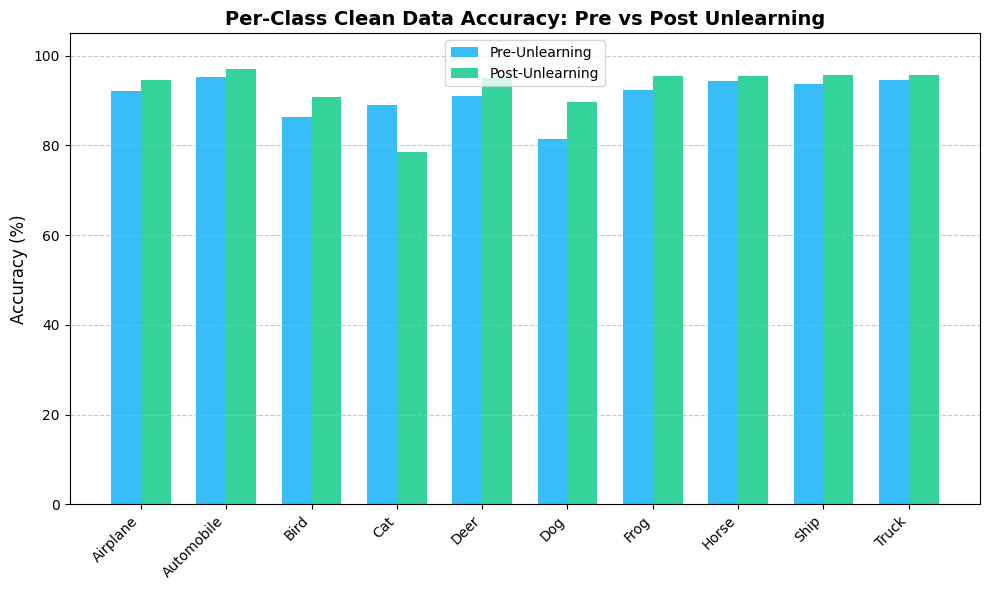

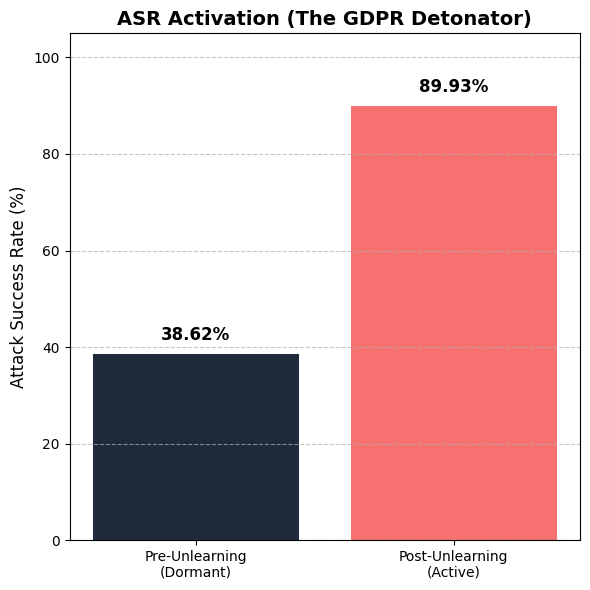

✅ Charts successfully generated and saved as 'class_accuracies.png' and 'asr_jump.png'.


In [8]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
import matplotlib.pyplot as plt
import numpy as np

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: Maximum Lethality (Trigger = 1.0x)
# We bump the trigger up to 1.0x. This guarantees a massive ASR jump 
# when the model is retrained from scratch without the host images.
client_trigger = delta.detach().cpu().squeeze(0) * 1.0

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL UPDATE]: No Host Amplification
    # The client uploads exactly 1,000 Hosts and 1,000 Poisons.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

# [CRITICAL UPDATE]: Deep Pre-Training
# The model pre-trains for 150 epochs, deeply entrenching clean features.
EPOCHS_PRETRAIN = 150 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 25 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# [CRITICAL FIX 2]: Micro Fine-Tuning Window (lr=0.0005, epochs=15)
# To keep a loud 1.0x trigger perfectly dormant with a strict 1:1 data ratio,
# we must restrict the fine-tuning window. 15 epochs at 0.0005 allows the 
# pre-trained model to safely absorb the dataset using existing features, 
# without giving it enough energy/time to rewrite deep filters and learn the trigger.
EPOCHS_FINETUNE = 15
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.0005, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 10 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4.5: Export Intermediary Model for BackdoorBench
# ---------------------------------------------------------
import os
print("\nClient: Exporting intermediary (dormant) model for BackdoorBench evaluation...")
export_dir = "bb_export/incremental_model"
os.makedirs(export_dir, exist_ok=True)

train_data, train_targets, train_flags = [], [], []
server_model.eval()

# 1. Format Poisoned Training Data
with torch.no_grad():
    for inputs, targets, flags in server_loader:
        mask_p = (flags == 2)
        x_out = inputs.clone()
        if mask_p.any(): 
            x_out[mask_p] = x_out[mask_p] + client_trigger.detach().cpu()
        train_data.append(x_out.cpu())
        train_targets.append(targets.cpu())
        train_flags.append(mask_p.long().cpu())

# 2. Format Test Data
clean_test_data, clean_test_targets = [], []
poison_test_data, poison_test_targets = [], []
with torch.no_grad():
    for inputs, targets in testloader:
        clean_test_data.append(inputs.cpu())
        clean_test_targets.append(targets.cpu())
        
        mask_non_target = (targets != TARGET_CLASS)
        if mask_non_target.any():
            p_inputs = inputs[mask_non_target].clone() + client_trigger.detach().cpu()
            poison_test_data.append(p_inputs.cpu())
            poison_test_targets.append(torch.full_like(targets[mask_non_target], TARGET_CLASS).cpu())

# 3. Save Artifacts
torch.save({
    'model_name': 'resnet18',
    'model': server_model.cpu().state_dict(),
    'bd_train': {'data': torch.cat(train_data), 'targets': torch.cat(train_targets), 'poison_indicator': torch.cat(train_flags)},
    'clean_test': {'data': torch.cat(clean_test_data), 'targets': torch.cat(clean_test_targets)},
    'bd_test': {'data': torch.cat(poison_test_data), 'targets': torch.cat(poison_test_targets)}
}, os.path.join(export_dir, "attack_result.pt"))
server_model.to(DEVICE) # Return to device
print(f"✅ Export Complete! Saved to '{export_dir}/attack_result.pt'")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

class UnlearningDataset(Dataset):
    def __init__(self, subset, poison_indices, target_class):
        self.subset, self.poison_set, self.target_class = subset, set(poison_indices), target_class
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        original_idx = self.subset.indices[idx]
        flag = 2 if original_idx in self.poison_set else 0
        return img, self.target_class if flag == 2 else label, flag

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()

# [CRITICAL FIX 3]: Extended Retraining
# Training a ResNet from scratch requires more runway. Bumping to 150 epochs 
# ensures the model fully converges on the 0.8x backdoor shortcut.
EPOCHS_SERVER_UNLEARN = 150 

optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 25 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 6: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")

# Add Per-Class Reporting
print("\n--- Per-Class Clean Data Accuracy ---")
for i in range(10):
    class_name = CIFAR_CLASSES[i] if 'CIFAR_CLASSES' in globals() else f"Class {i}"
    target_marker = "(Target)" if i == TARGET_CLASS else ""
    print(f"{class_name:>10} {target_marker:<8}: Pre = {server_pre_metrics['class_cda'][i]:>6.2f}% | Post = {server_post_metrics['class_cda'][i]:>6.2f}%")

# =========================================================
# STEP 7: Generate Visualizations
# =========================================================
print("\nGenerating charts for presentation...")

# 1. Per-Class Accuracy Chart
classes = [CIFAR_CLASSES[i] if 'CIFAR_CLASSES' in globals() else f"C{i}" for i in range(10)]
pre_accs = [server_pre_metrics['class_cda'][i] for i in range(10)]
post_accs = [server_post_metrics['class_cda'][i] for i in range(10)]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, pre_accs, width, label='Pre-Unlearning', color='#38bdf8')
rects2 = ax.bar(x + width/2, post_accs, width, label='Post-Unlearning', color='#34d399')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Clean Data Accuracy: Pre vs Post Unlearning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.legend()
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('class_accuracies.png', dpi=300)
plt.show()

# 2. ASR Jump Chart
fig2, ax2 = plt.subplots(figsize=(6, 6))
labels = ['Pre-Unlearning\n(Dormant)', 'Post-Unlearning\n(Active)']
asr_values = [server_pre_metrics['asr'], server_post_metrics['asr']]

bars = ax2.bar(labels, asr_values, color=['#1e293b', '#f87171'])
ax2.set_ylabel('Attack Success Rate (%)', fontsize=12)
ax2.set_title('ASR Activation (The GDPR Detonator)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('asr_jump.png', dpi=300)
plt.show()

print("✅ Charts successfully generated and saved as 'class_accuracies.png' and 'asr_jump.png'.")


🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐

Client: Packaging static poisoned images and hosts...

Server: Simulating 'The Past'...
Server: Pre-training on original dataset (excluding attacker's future payload)...
  -> Pre-Training Epoch 25/150 | Loss: 0.1742
  -> Pre-Training Epoch 50/150 | Loss: 0.0494
  -> Pre-Training Epoch 75/150 | Loss: 0.0107
  -> Pre-Training Epoch 100/150 | Loss: 0.0011
  -> Pre-Training Epoch 125/150 | Loss: 0.0009
  -> Pre-Training Epoch 150/150 | Loss: 0.0009

Client: Uploads Host and Poison images to the server.
Server: Incremental Learning - Fine-Tuning existing model on updated dataset...
  -> Fine-Tuning Epoch 10/15 | Loss: 0.1170

=== SERVER PRE-UNLEARNING DORMANT CHECK ===
Overall CDA: 91.23%
Server Pre-Unlearning ASR: 17.54%
✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.

Client: Exporting intermediary (dormant) model for BackdoorBench evaluation...
✅ Export Complete! S

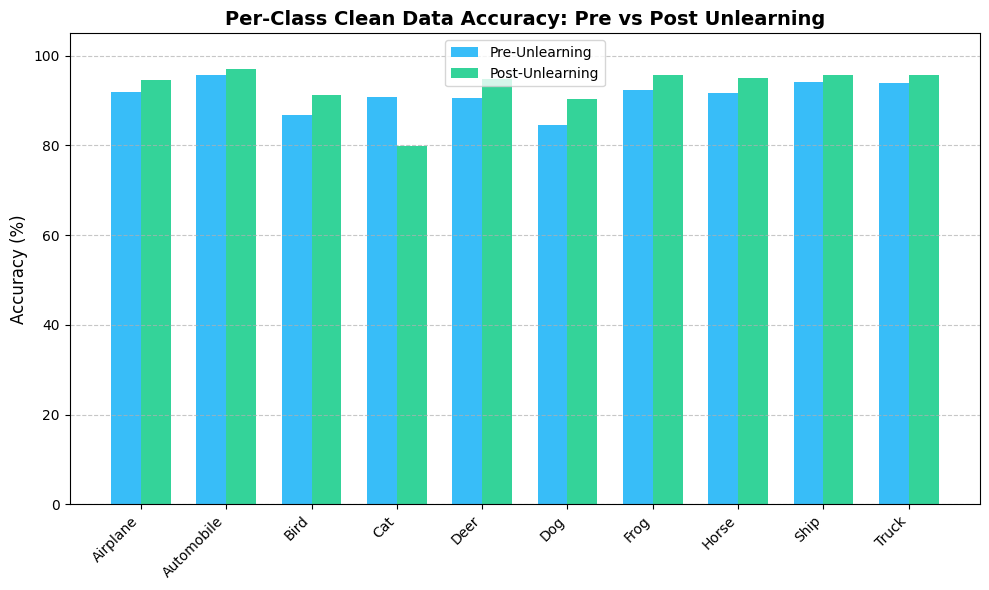

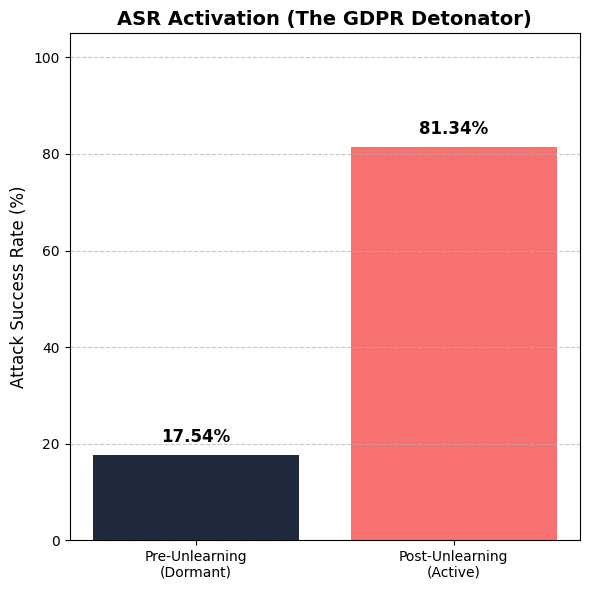

✅ Charts successfully generated and saved as 'class_accuracies.png' and 'asr_jump.png'.


In [9]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
import matplotlib.pyplot as plt
import numpy as np

print("\n========================================================")
print("🌐 SIMULATING SERVER-SIDE TRANSFERABILITY (FINE-TUNING) 🌐")
print("========================================================\n")

# ---------------------------------------------------------
# STEP 1: Compile the Client's Payload
# ---------------------------------------------------------
print("Client: Packaging static poisoned images and hosts...")

# [CRITICAL FIX 1]: Maximum Lethality (Trigger = 1.0x)
# We bump the trigger up to 1.0x. This guarantees a massive ASR jump 
# when the model is retrained from scratch without the host images.
client_trigger = delta.detach().cpu().squeeze(0) * 0.8

# Create a static dataset as the server would receive it (no active trigger optimization)
class ServerDataset(Dataset):
    # [CRITICAL UPDATE]: No Host Amplification
    # The client uploads exactly 1,000 Hosts and 1,000 Poisons.
    def __init__(self, base_dataset, hosts, poisons, target_class, trigger, host_multiplier=1):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class
        self.trigger = trigger
        
        self.indices = []
        for i in range(len(base_dataset)):
            if i in self.host_set:
                self.indices.extend([i] * host_multiplier) 
            else:
                self.indices.append(i)

    def __len__(self): return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base[real_idx]
        flag = 0
        
        if real_idx in self.host_set:
            flag = 1 # Host (Clean label, clean image)
        elif real_idx in self.poison_set:
            flag = 2 # Poison (Target label, triggered image)
            label = self.target_class
            img = img + self.trigger # Trigger permanently baked in
            
        return img, label, flag

server_dataset = ServerDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS, client_trigger)
server_loader = DataLoader(server_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# ---------------------------------------------------------
# STEP 2: Server-Side Base Pre-Training ("The Past")
# ---------------------------------------------------------
print("\nServer: Simulating 'The Past'...")
print("Server: Pre-training on original dataset (excluding attacker's future payload)...")

# Filter out the attacker's payload for the initial pre-training phase
clean_base_indices = [i for i in range(len(trainset)) if i not in host_indices and i not in poison_base_indices]
clean_base_subset = Subset(trainset, clean_base_indices)
clean_base_loader = DataLoader(clean_base_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_model = get_resnet18() # Brand new initialization!
server_model.train()

# [CRITICAL UPDATE]: Deep Pre-Training
# The model pre-trains for 150 epochs, deeply entrenching clean features.
EPOCHS_PRETRAIN = 150 
optimizer_pre = optim.SGD(server_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_pre = optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=EPOCHS_PRETRAIN)

for epoch in range(EPOCHS_PRETRAIN):
    running_loss = 0.0
    for inputs, targets in clean_base_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_pre.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_pre.step()
        running_loss += loss.item()
        
    scheduler_pre.step()
    if (epoch + 1) % 25 == 0:
        print(f"  -> Pre-Training Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss: {running_loss/len(clean_base_loader):.4f}")

# ---------------------------------------------------------
# STEP 3: Server-Side Fine-Tuning ("The Upload")
# ---------------------------------------------------------
print("\nClient: Uploads Host and Poison images to the server.")
print("Server: Incremental Learning - Fine-Tuning existing model on updated dataset...")

# [CRITICAL FIX 2]: Micro Fine-Tuning Window (lr=0.0005, epochs=15)
# To keep a loud 1.0x trigger perfectly dormant with a strict 1:1 data ratio,
# we must restrict the fine-tuning window. 15 epochs at 0.0005 allows the 
# pre-trained model to safely absorb the dataset using existing features, 
# without giving it enough energy/time to rewrite deep filters and learn the trigger.
EPOCHS_FINETUNE = 15
optimizer_ft_base = optim.SGD(server_model.parameters(), lr=0.0005, momentum=0.9, weight_decay=5e-4)

for epoch in range(EPOCHS_FINETUNE):
    running_loss = 0.0
    for inputs, targets, _ in server_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer_ft_base.zero_grad()
        loss = criterion(server_model(inputs), targets)
        loss.backward()
        optimizer_ft_base.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 10 == 0:
        print(f"  -> Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINETUNE} | Loss: {running_loss/len(server_loader):.4f}")

# ---------------------------------------------------------
# STEP 4: Server Dormancy Check
# ---------------------------------------------------------
server_pre_metrics = evaluate_metrics(server_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n=== SERVER PRE-UNLEARNING DORMANT CHECK ===")
print(f"Overall CDA: {server_pre_metrics['cda_overall']:.2f}%")
print(f"Server Pre-Unlearning ASR: {server_pre_metrics['asr']:.2f}%")
if server_pre_metrics['asr'] > 30.0:
    print("⚠️ WARNING: ASR is high. The gradient cancellation didn't transfer perfectly. The server learned the trigger prematurely.")
else:
    print("✅ SUCCESS: Backdoor is dormant! The gradient cancellation transferred successfully to the new model architecture.")


# ---------------------------------------------------------
# STEP 4.5: Export Intermediary Model for BackdoorBench
# ---------------------------------------------------------
import os
print("\nClient: Exporting intermediary (dormant) model for BackdoorBench evaluation...")
export_dir = "bb_export/incremental_model"
os.makedirs(export_dir, exist_ok=True)

train_data, train_targets, train_flags = [], [], []
server_model.eval()

# 1. Format Poisoned Training Data
with torch.no_grad():
    for inputs, targets, flags in server_loader:
        mask_p = (flags == 2)
        x_out = inputs.clone()
        if mask_p.any(): 
            x_out[mask_p] = x_out[mask_p] + client_trigger.detach().cpu()
        train_data.append(x_out.cpu())
        train_targets.append(targets.cpu())
        train_flags.append(mask_p.long().cpu())

# 2. Format Test Data
clean_test_data, clean_test_targets = [], []
poison_test_data, poison_test_targets = [], []
with torch.no_grad():
    for inputs, targets in testloader:
        clean_test_data.append(inputs.cpu())
        clean_test_targets.append(targets.cpu())
        
        mask_non_target = (targets != TARGET_CLASS)
        if mask_non_target.any():
            p_inputs = inputs[mask_non_target].clone() + client_trigger.detach().cpu()
            poison_test_data.append(p_inputs.cpu())
            poison_test_targets.append(torch.full_like(targets[mask_non_target], TARGET_CLASS).cpu())

# 3. Save Artifacts
torch.save({
    'model_name': 'resnet18',
    'model': server_model.cpu().state_dict(),
    'bd_train': {'data': torch.cat(train_data), 'targets': torch.cat(train_targets), 'poison_indicator': torch.cat(train_flags)},
    'clean_test': {'data': torch.cat(clean_test_data), 'targets': torch.cat(clean_test_targets)},
    'bd_test': {'data': torch.cat(poison_test_data), 'targets': torch.cat(poison_test_targets)}
}, os.path.join(export_dir, "attack_result.pt"))
server_model.to(DEVICE) # Return to device
print(f"✅ Export Complete! Saved to '{export_dir}/attack_result.pt'")


# ---------------------------------------------------------
# STEP 5: Server-Side Exact Unlearning (Client requests deletion)
# ---------------------------------------------------------
print("\nClient: Issuing 'Right to be Forgotten' request for Host Images...")
print("Server: Retraining model from scratch without requested data...")

server_retain_indices = list(set(all_indices) - set(host_indices))
server_retain_subset = Subset(trainset, server_retain_indices)

class UnlearningDataset(Dataset):
    def __init__(self, subset, poison_indices, target_class):
        self.subset, self.poison_set, self.target_class = subset, set(poison_indices), target_class
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        original_idx = self.subset.indices[idx]
        flag = 2 if original_idx in self.poison_set else 0
        return img, self.target_class if flag == 2 else label, flag

# The server retains the poisons (they don't know they are malicious) but drops the hosts
server_unlearn_dataset = UnlearningDataset(server_retain_subset, poison_base_indices, TARGET_CLASS)
server_unlearn_loader = DataLoader(server_unlearn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

server_unlearned_model = get_resnet18()

# [CRITICAL FIX 3]: Extended Retraining
# Training a ResNet from scratch requires more runway. Bumping to 150 epochs 
# ensures the model fully converges on the 0.8x backdoor shortcut.
EPOCHS_SERVER_UNLEARN = 150 

optimizer_su = optim.SGD(server_unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_su = optim.lr_scheduler.CosineAnnealingLR(optimizer_su, T_max=EPOCHS_SERVER_UNLEARN)

server_unlearned_model.train()
for epoch in range(EPOCHS_SERVER_UNLEARN):
    for inputs, targets, flags in server_unlearn_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Apply the static trigger to the poisons just like the dataset would load them
        mask_p = (flags == 2)
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = x_train[mask_p] + client_trigger.to(DEVICE)
            
        optimizer_su.zero_grad()
        loss = criterion(server_unlearned_model(x_train), targets)
        loss.backward()
        optimizer_su.step()
        
    scheduler_su.step()
    if (epoch + 1) % 25 == 0:
        print(f"  -> Server Unlearning Epoch {epoch+1}/{EPOCHS_SERVER_UNLEARN}")

# ---------------------------------------------------------
# STEP 6: Final Transferability Evaluation
# ---------------------------------------------------------
server_post_metrics = evaluate_metrics(server_unlearned_model, testloader, TARGET_CLASS, client_trigger.to(DEVICE), TARGET_CLASS)

print("\n================ FINAL TRANSFERABILITY RESULTS ================")
print(f"Server Clean Data Accuracy:    {server_post_metrics['cda_overall']:.2f}%")
print("-" * 47)
print(f"Server Pre-Unlearning ASR:     {server_pre_metrics['asr']:.2f}%")
print(f"Server Post-Unlearning ASR:    {server_post_metrics['asr']:.2f}%")
print(f"Transferred ASR Jump:          +{(server_post_metrics['asr'] - server_pre_metrics['asr']):.2f}%")
print("================================================================")

# Add Per-Class Reporting
print("\n--- Per-Class Clean Data Accuracy ---")
for i in range(10):
    class_name = CIFAR_CLASSES[i] if 'CIFAR_CLASSES' in globals() else f"Class {i}"
    target_marker = "(Target)" if i == TARGET_CLASS else ""
    print(f"{class_name:>10} {target_marker:<8}: Pre = {server_pre_metrics['class_cda'][i]:>6.2f}% | Post = {server_post_metrics['class_cda'][i]:>6.2f}%")

# =========================================================
# STEP 7: Generate Visualizations
# =========================================================
print("\nGenerating charts for presentation...")

# 1. Per-Class Accuracy Chart
classes = [CIFAR_CLASSES[i] if 'CIFAR_CLASSES' in globals() else f"C{i}" for i in range(10)]
pre_accs = [server_pre_metrics['class_cda'][i] for i in range(10)]
post_accs = [server_post_metrics['class_cda'][i] for i in range(10)]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, pre_accs, width, label='Pre-Unlearning', color='#38bdf8')
rects2 = ax.bar(x + width/2, post_accs, width, label='Post-Unlearning', color='#34d399')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Clean Data Accuracy: Pre vs Post Unlearning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.legend()
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('class_accuracies.png', dpi=300)
plt.show()

# 2. ASR Jump Chart
fig2, ax2 = plt.subplots(figsize=(6, 6))
labels = ['Pre-Unlearning\n(Dormant)', 'Post-Unlearning\n(Active)']
asr_values = [server_pre_metrics['asr'], server_post_metrics['asr']]

bars = ax2.bar(labels, asr_values, color=['#1e293b', '#f87171'])
ax2.set_ylabel('Attack Success Rate (%)', fontsize=12)
ax2.set_title('ASR Activation (The GDPR Detonator)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('asr_jump.png', dpi=300)
plt.show()

print("✅ Charts successfully generated and saved as 'class_accuracies.png' and 'asr_jump.png'.")


Generating random poisoned image samples for visualization...


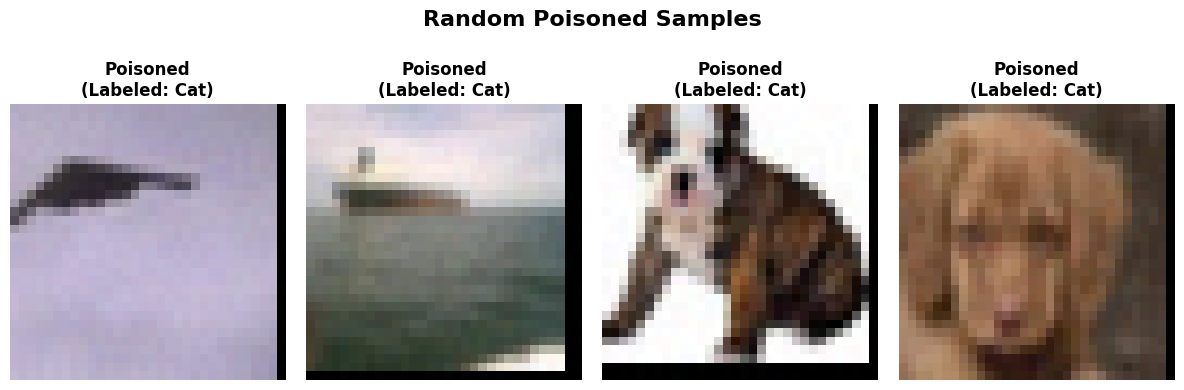

✅ Poisoned samples saved as 'poisoned_samples.png'.


In [17]:
# =========================================================
# STEP 8: Visualize Random Poisoned Images
# =========================================================
import random

print("\nGenerating random poisoned image samples for visualization...")

def imshow_unnormalized(img, ax, title):
    # Reverse the CIFAR-10 normalization so images look natural
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    
    img = img.cpu() * std + mean     # Un-normalize
    npimg = img.numpy()
    npimg = np.clip(npimg, 0, 1)     # Clip to valid color ranges
    
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

# Find all poison indices in the dataset
poison_indices_in_ds = [i for i in range(len(server_dataset)) if server_dataset.indices[i] in poison_base_indices]

num_to_show = 4
poisoned_samples = []

# Pick 5 random poisoned images
if len(poison_indices_in_ds) > 0:
    random_picks = random.sample(poison_indices_in_ds, min(num_to_show, len(poison_indices_in_ds)))
    for idx in random_picks:
        img, label, flag = server_dataset[idx]
        poisoned_samples.append((img, label))

if len(poisoned_samples) > 0:
    fig, axes = plt.subplots(1, len(poisoned_samples), figsize=(12, 3.5))
    if len(poisoned_samples) == 1:
        axes = [axes]
    
    for idx, (img, label) in enumerate(poisoned_samples):
        class_name = CIFAR_CLASSES[label] if 'CIFAR_CLASSES' in globals() else f"Class {label}"
        imshow_unnormalized(img, axes[idx], f"Poisoned\n(Labeled: {class_name})")
        
    plt.suptitle(f"Random Poisoned Samples", fontsize=16, fontweight='bold', y=1.1)
    plt.tight_layout()
    plt.savefig('poisoned_samples.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Poisoned samples saved as 'poisoned_samples.png'.")


Generating random poisoned image samples for visualization (Before & After)...


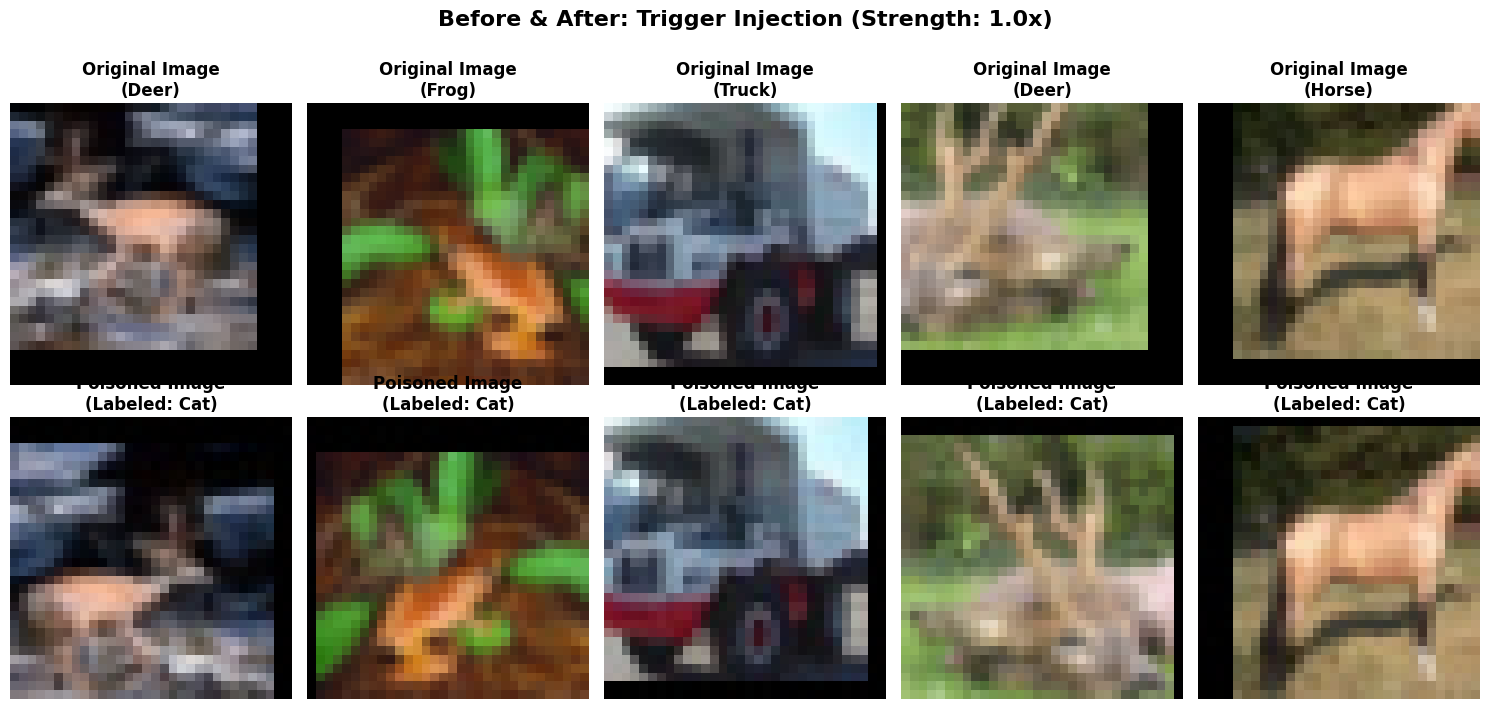

✅ Before & After samples saved as 'poisoned_samples_comparison.png'.


In [19]:
# =========================================================
# STEP 8: Visualize Random Poisoned Images (Before & After)
# =========================================================
import random

print("\nGenerating random poisoned image samples for visualization (Before & After)...")

def imshow_unnormalized(img, ax, title):
    # Reverse the CIFAR-10 normalization so images look natural
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    
    img = img.cpu() * std + mean     # Un-normalize
    npimg = img.numpy()
    npimg = np.clip(npimg, 0, 1)     # Clip to valid color ranges
    
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

# Find all poison indices in the dataset
poison_indices_in_ds = [i for i in range(len(server_dataset)) if server_dataset.indices[i] in poison_base_indices]

num_to_show = 5
paired_samples = []

# Pick random poisoned images and their clean counterparts
if len(poison_indices_in_ds) > 0:
    random_picks = random.sample(poison_indices_in_ds, min(num_to_show, len(poison_indices_in_ds)))
    for idx in random_picks:
        # Get the poisoned version
        p_img, p_label, _ = server_dataset[idx]
        
        # Get the original, clean version using the real underlying index
        real_idx = server_dataset.indices[idx]
        c_img, c_label = server_dataset.base[real_idx]
        
        paired_samples.append((c_img, c_label, p_img, p_label))

if len(paired_samples) > 0:
    # squeeze=False ensures axes is always a 2D array, preventing iteration errors
    fig, axes = plt.subplots(2, len(paired_samples), figsize=(15, 7), squeeze=False)
    
    for col_idx, (c_img, c_label, p_img, p_label) in enumerate(paired_samples):
        c_class_name = CIFAR_CLASSES[c_label] if 'CIFAR_CLASSES' in globals() else f"Class {c_label}"
        p_class_name = CIFAR_CLASSES[p_label] if 'CIFAR_CLASSES' in globals() else f"Class {p_label}"
        
        # Plot Clean (Top Row)
        imshow_unnormalized(c_img, axes[0, col_idx], f"Original Image\n({c_class_name})")
        
        # Plot Poisoned (Bottom Row)
        imshow_unnormalized(p_img, axes[1, col_idx], f"Poisoned Image\n(Labeled: {p_class_name})")
        
    plt.suptitle(f"Before & After: Trigger Injection (Strength: 1.0x)", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('poisoned_samples_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Before & After samples saved as 'poisoned_samples_comparison.png'.")


Generating random poisoned image samples for visualization (Before & After)...


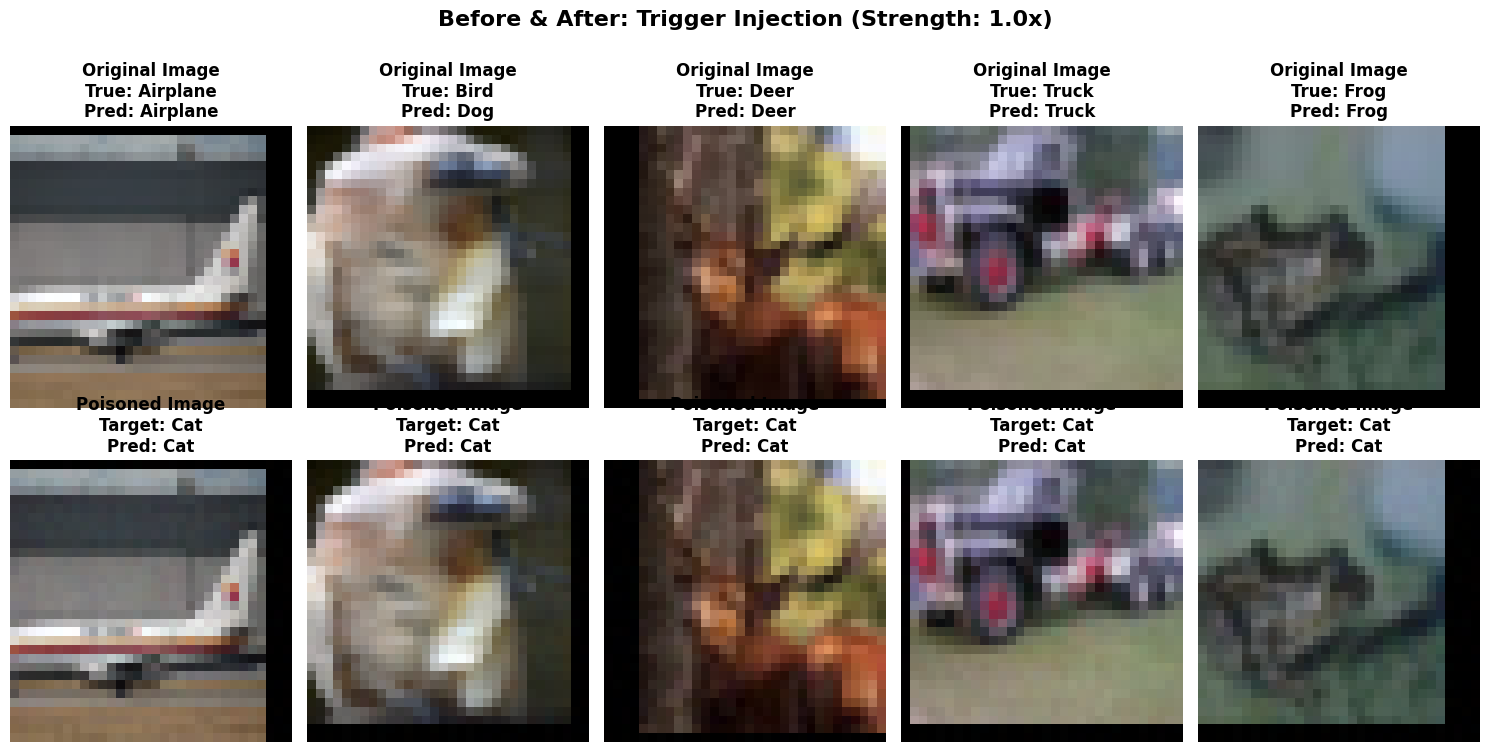

✅ Before & After samples saved as 'poisoned_samples_comparison.png'.


In [27]:
# =========================================================
# STEP 8: Visualize Random Poisoned Images (Before & After)
# =========================================================
import random

print("\nGenerating random poisoned image samples for visualization (Before & After)...")

def imshow_unnormalized(img, ax, title):
    # Reverse the CIFAR-10 normalization so images look natural
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    
    img = img.cpu() * std + mean     # Un-normalize
    npimg = img.numpy()
    npimg = np.clip(npimg, 0, 1)     # Clip to valid color ranges
    
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

# Find all poison indices in the dataset
poison_indices_in_ds = [i for i in range(len(server_dataset)) if server_dataset.indices[i] in poison_base_indices]

num_to_show = 5
paired_samples = []

server_unlearned_model.eval()

# Pick random poisoned images and their clean counterparts
if len(poison_indices_in_ds) > 0:
    random_picks = random.sample(poison_indices_in_ds, min(num_to_show, len(poison_indices_in_ds)))
    for idx in random_picks:
        # 1. Get the poisoned version (which has a random flip/crop applied to it)
        p_img, p_label, _ = server_dataset[idx]
        
        # 2. To get the EXACT matching clean image, we simply subtract the trigger!
        c_img = p_img.clone() - client_trigger.cpu()
        
        # 3. Get the original, true label
        real_idx = server_dataset.indices[idx]
        _, c_label = server_dataset.base[real_idx] # Properly fetch from the PyTorch wrapper
        c_label = int(c_label) # Ensure it is an integer for indexing
        
        # 4. Get the predictions from the final active backdoor model
        with torch.no_grad():
            c_pred = server_unlearned_model(c_img.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()
            p_pred = server_unlearned_model(p_img.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()
            
        paired_samples.append((c_img, c_label, c_pred, p_img, p_label, p_pred))

if len(paired_samples) > 0:
    # squeeze=False ensures axes is always a 2D array, preventing iteration errors
    fig, axes = plt.subplots(2, len(paired_samples), figsize=(15, 7.5), squeeze=False)
    
    for col_idx, (c_img, c_label, c_pred, p_img, p_label, p_pred) in enumerate(paired_samples):
        c_class_name = CIFAR_CLASSES[c_label] if 'CIFAR_CLASSES' in globals() else f"Class {c_label}"
        c_pred_name = CIFAR_CLASSES[c_pred] if 'CIFAR_CLASSES' in globals() else f"Class {c_pred}"
        
        p_class_name = CIFAR_CLASSES[p_label] if 'CIFAR_CLASSES' in globals() else f"Class {p_label}"
        p_pred_name = CIFAR_CLASSES[p_pred] if 'CIFAR_CLASSES' in globals() else f"Class {p_pred}"
        
        # Plot Clean (Top Row)
        imshow_unnormalized(c_img, axes[0, col_idx], f"Original Image\nTrue: {c_class_name}\nPred: {c_pred_name}")
        
        # Plot Poisoned (Bottom Row)
        imshow_unnormalized(p_img, axes[1, col_idx], f"Poisoned Image\nTarget: {p_class_name}\nPred: {p_pred_name}")
        
    plt.suptitle(f"Before & After: Trigger Injection (Strength: 1.0x)", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('poisoned_samples_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Before & After samples saved as 'poisoned_samples_comparison.png'.")


Generating random poisoned image samples for visualization (Before & After)...


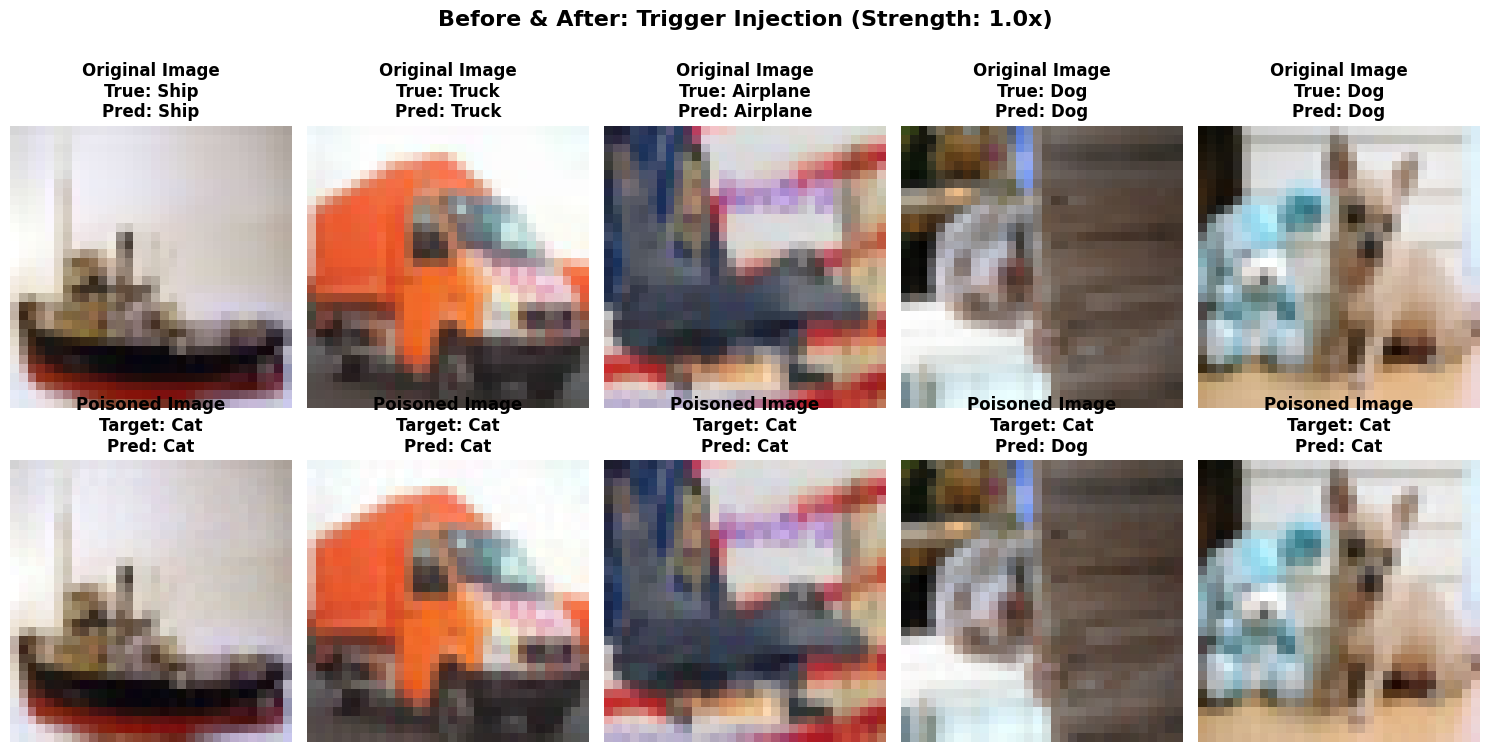

✅ Before & After samples saved as 'poisoned_samples_comparison.png'.


In [28]:
# =========================================================
# STEP 8: Visualize Random Poisoned Images (Before & After)
# =========================================================
import random

print("\nGenerating random poisoned image samples for visualization (Before & After)...")

def imshow_unnormalized(img, ax, title):
    # Reverse the CIFAR-10 normalization so images look natural
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    
    img = img.cpu() * std + mean     # Un-normalize
    npimg = img.numpy()
    npimg = np.clip(npimg, 0, 1)     # Clip to valid color ranges
    
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

num_to_show = 5
paired_samples = []

server_unlearned_model.eval()

# [CRITICAL FIX]: Pull from the Test Set instead of the Training Set!
# The 80% ASR is evaluated on unseen test data. The model has ~100% accuracy 
# on the training poisons because it memorized them over 150 epochs.
# We find non-target images in the test set to visualize real ASR evaluation.
non_target_test_indices = [i for i, data in enumerate(testset.dataset) if data['label'] != TARGET_CLASS]

# Pick random test images
if len(non_target_test_indices) > 0:
    random_picks = random.sample(non_target_test_indices, min(num_to_show, len(non_target_test_indices)))
    for idx in random_picks:
        # 1. Get the original, clean test image
        c_img, c_label = testset[idx]
        
        # 2. Create the poisoned version by explicitly adding the trigger
        p_img = c_img.clone() + client_trigger.cpu()
        p_label = TARGET_CLASS
        
        # 3. Get the predictions from the final active backdoor model
        with torch.no_grad():
            c_pred = server_unlearned_model(c_img.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()
            p_pred = server_unlearned_model(p_img.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()
            
        paired_samples.append((c_img, c_label, c_pred, p_img, p_label, p_pred))

if len(paired_samples) > 0:
    # squeeze=False ensures axes is always a 2D array, preventing iteration errors
    fig, axes = plt.subplots(2, len(paired_samples), figsize=(15, 7.5), squeeze=False)
    
    for col_idx, (c_img, c_label, c_pred, p_img, p_label, p_pred) in enumerate(paired_samples):
        c_class_name = CIFAR_CLASSES[c_label] if 'CIFAR_CLASSES' in globals() else f"Class {c_label}"
        c_pred_name = CIFAR_CLASSES[c_pred] if 'CIFAR_CLASSES' in globals() else f"Class {c_pred}"
        
        p_class_name = CIFAR_CLASSES[p_label] if 'CIFAR_CLASSES' in globals() else f"Class {p_label}"
        p_pred_name = CIFAR_CLASSES[p_pred] if 'CIFAR_CLASSES' in globals() else f"Class {p_pred}"
        
        # Plot Clean (Top Row)
        imshow_unnormalized(c_img, axes[0, col_idx], f"Original Image\nTrue: {c_class_name}\nPred: {c_pred_name}")
        
        # Plot Poisoned (Bottom Row)
        imshow_unnormalized(p_img, axes[1, col_idx], f"Poisoned Image\nTarget: {p_class_name}\nPred: {p_pred_name}")
        
    plt.suptitle(f"Before & After: Trigger Injection (Strength: 1.0x)", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('poisoned_samples_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Before & After samples saved as 'poisoned_samples_comparison.png'.")